SEASONAL ENIGH DATASETS

In [1]:
from pathlib import Path
import pandas as pd

ENIGH_DIR = Path(r"D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E")

gsh_path = ENIGH_DIR / "gastoshogar.csv"
gsh = pd.read_csv(gsh_path, low_memory=False, dtype={"clave": "string"})
gsh.shape, gsh["clave"].dropna().head()


((2640557, 27),
 0    C006
 1    D014
 2    D015
 3    D022
 4    E022
 Name: clave, dtype: string)

In [2]:
#DESCARGA DICCINARIO
URL_GSH_CLAVE = "https://www.inegi.org.mx/rnm/index.php/metadata/export_variable/934/V5430/csv"

dic_raw = pd.read_csv(URL_GSH_CLAVE)
dic_raw.head(), dic_raw.columns


(                               survey_idno  sid file_id    vid   name  \
 0  MEX-INEGI.ESD3.03-ENIGH-2022-ESTACIONAL  934    F113  V5430  clave   
 
              labl var_intrvl  var_dcml  var_wgt  var_start_pos  ...  \
 0  Clave de gasto   discrete       NaN      NaN            NaN  ...   
 
    var_qstn_postqtxt  var_qstn_ivulnstr        var_universe  \
 0                NaN                NaN  Todos los hogares.   
 
                                          var_sumstat  \
 0  [{"value":"2640557","type":"vald","wgtd":null}...   
 
                                              var_txt  \
 0  Producto, bien o servicio adquirido por los in...   
 
                                           var_catgry var_codinstr  \
 0  [{"value":"A001","labl":"Ma\u00edz en grano (d...          NaN   
 
    var_concept                                         var_format var_notes  
 0           []  {"type":"character","schema":"other","category...       NaN  
 
 [1 rows x 27 columns],
 Index(['survey_

In [3]:
import json
import pandas as pd

# dic_raw ya lo tienes
meta = dic_raw.iloc[0]

# var_catgry viene como string tipo JSON -> lo parseamos
cat = meta["var_catgry"]
if isinstance(cat, str):
    cat = json.loads(cat)

# Formatos comunes: {"category": [...]} o {"categories": [...]} o lista directa
if isinstance(cat, dict):
    cats = cat.get("category") or cat.get("categories") or cat.get("catgry") or cat.get("catgry_val") or []
elif isinstance(cat, list):
    cats = cat
else:
    cats = []

dic = pd.DataFrame(cats)

# Normaliza nombres típicos
dic = dic.rename(columns={"value": "clave", "labl": "descripcion"})
dic = dic[["clave", "descripcion"]].copy()
dic["clave"] = dic["clave"].astype("string").str.strip()
dic["descripcion"] = dic["descripcion"].astype("string").str.strip()

dic.head(), dic.shape


(  clave                                        descripcion
 0  A001               Maíz en grano (de todo tipo y color)
 1  A002  Harina de maíz, maicena, fécula, nixtamalizada...
 2  A003                Masa de maíz (de todo tipo y color)
 3  A004            Tortilla de maíz (de todo tipo y color)
 4  A005    Tostadas, raspadas, tostitos, totopos, tlayudas,
 (762, 2))

In [4]:
#HACER EL CRUCE
from pathlib import Path
import pandas as pd

ENIGH_DIR = Path(r"D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E")
OUT_DIR = ENIGH_DIR / "03_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 1) cargar tus gastos del hogar
gsh = pd.read_csv(ENIGH_DIR / "gastoshogar.csv", low_memory=False, dtype={"clave": "string"})
gsh["clave"] = gsh["clave"].str.strip()

# 2) claves que aparecen en tu base
claves_en_base = gsh[["clave"]].dropna().drop_duplicates()

# 3) merge con diccionario
tabla = (
    claves_en_base
    .merge(dic, on="clave", how="left")
    .sort_values("clave")
    .reset_index(drop=True)
)

# 4) guardar
tabla.to_csv(OUT_DIR / "enigh_clave_significado.csv", index=False)

# 5) QC
print("Claves únicas en gastoshogar:", len(claves_en_base))
print("Sin descripción:", int(tabla["descripcion"].isna().sum()))
print("Porcentaje sin descripción:", float(tabla["descripcion"].isna().mean()))
tabla.head(20)


Claves únicas en gastoshogar: 755
Sin descripción: 0
Porcentaje sin descripción: 0.0


,clave,descripcion
0,A001,Maíz en grano (de todo tipo y color)
1,A002,"Harina de maíz, maicena, fécula, nixtamalizada..."
2,A003,Masa de maíz (de todo tipo y color)
3,A004,Tortilla de maíz (de todo tipo y color)
4,A005,"Tostadas, raspadas, tostitos, totopos, tlayudas"
5,A006,Otros productos de maíz (excepto cereal)
6,A007,Harina de trigo
7,A008,Tortilla de harina
8,A009,Pasta para sopa
9,A010,Galletas dulces


In [5]:
top15 = ["F007","A244","G101","M007","N013","A202","A004","G009","R001","A243","F003","A220","M008","A093","A075"]
top15_tabla = pd.DataFrame({"clave": top15}).merge(dic, on="clave", how="left")
top15_tabla


,clave,descripcion
0,F007,Gasolina Magna
1,A244,Comida
2,G101,Renta o alquiler de la vivienda
3,M007,Automóvil y/o guayín
4,N013,"Ayuda a parientes y personas ajenas al hogar, ..."
5,A202,"Otros alimentos preparados: atole, flautas, gu..."
6,A004,Tortilla de maíz (de todo tipo y color)
7,G009,Gas licuado de petróleo
8,R001,Energía eléctrica
9,A243,Desayuno


In [6]:
#gastoshogat+ gastospersona

import json
import pandas as pd

def extract_dic_from_rnm(url: str) -> pd.DataFrame:
    meta = pd.read_csv(url).iloc[0]
    cat = meta["var_catgry"]
    if isinstance(cat, str):
        cat = json.loads(cat)
    if isinstance(cat, dict):
        cats = cat.get("category") or cat.get("categories") or []
    elif isinstance(cat, list):
        cats = cat
    else:
        cats = []
    out = pd.DataFrame(cats).rename(columns={"value": "clave", "labl": "descripcion"})[["clave", "descripcion"]]
    out["clave"] = out["clave"].astype("string").str.strip()
    out["descripcion"] = out["descripcion"].astype("string").str.strip()
    return out.dropna(subset=["clave"]).drop_duplicates("clave").reset_index(drop=True)

URL_GSH = "https://www.inegi.org.mx/rnm/index.php/metadata/export_variable/934/V5430/csv"  # gastoshogar.clave
URL_GSP = "https://www.inegi.org.mx/rnm/index.php/metadata/export_variable/934/V5497/csv"  # gastospersona.clave

dic_gsh = extract_dic_from_rnm(URL_GSH)
dic_gsp = extract_dic_from_rnm(URL_GSP)

dic_all = (
    pd.concat([dic_gsh, dic_gsp], ignore_index=True)
    .drop_duplicates("clave")
    .sort_values("clave")
    .reset_index(drop=True)
)

dic_gsh.shape, dic_gsp.shape, dic_all.shape


((762, 2), (746, 2), (762, 2))

In [7]:
#dieganostico
set_gsh = set(dic_gsh["clave"])
set_gsp = set(dic_gsp["clave"])

solo_gsp = sorted(set_gsp - set_gsh)
solo_gsh = sorted(set_gsh - set_gsp)
inter = sorted(set_gsh & set_gsp)

len(solo_gsp), len(solo_gsh), len(inter), solo_gsp[:20]


(0, 16, 746, [])

In [8]:
dic_all = pd.concat([dic_gsh, dic_gsp], ignore_index=True)

# score: prioriza descripción no nula y más larga
dic_all["desc_len"] = dic_all["descripcion"].fillna("").astype(str).str.len()
dic_all["has_desc"] = dic_all["descripcion"].notna().astype(int)

dic_all = (
    dic_all.sort_values(["clave", "has_desc", "desc_len"], ascending=[True, False, False])
    .drop_duplicates("clave", keep="first")
    .drop(columns=["desc_len", "has_desc"])
    .sort_values("clave")
    .reset_index(drop=True)
)

dic_all.shape


(762, 2)

In [9]:
conf = (
    pd.concat([dic_gsh.assign(src="gsh"), dic_gsp.assign(src="gsp")], ignore_index=True)
    .dropna(subset=["descripcion"])
)

conflicts = (
    conf.groupby("clave")["descripcion"].nunique()
    .reset_index(name="n_desc")
    .query("n_desc > 1")
)

conflicts.head(), len(conflicts)


(    clave  n_desc
 64   A065       2
 70   A071       2
 289  D012       2
 337  E034       2
 386  H013       2,
 58)

In [10]:
from pathlib import Path
import pandas as pd

ENIGH_DIR = Path(r"D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E")
OUT_DIR = ENIGH_DIR / "03_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Load
gsh = pd.read_csv(ENIGH_DIR / "gastoshogar.csv", low_memory=False, dtype={"clave": "string"})
con = pd.read_csv(ENIGH_DIR / "concentradohogar.csv", low_memory=False)

# --- Normalize
gsh["clave"] = gsh["clave"].astype("string").str.strip()

sexo_map = {1: "Hombre", 2: "Mujer"}
con["grupo"] = pd.to_numeric(con["sexo_jefe"], errors="coerce").map(sexo_map)

# --- Pick weight column (factor_t preferred)
wcol = "factor_t" if "factor_t" in con.columns else "factor"
con[wcol] = pd.to_numeric(con[wcol], errors="coerce")

# --- Pick amount column (quarterly preferred)
amt = "gasto_tri" if "gasto_tri" in gsh.columns else "gasto"
gsh[amt] = pd.to_numeric(gsh[amt], errors="coerce").fillna(0.0)

# --- Merge
df = gsh.merge(
    con[["folioviv", "foliohog", "grupo", wcol]],
    on=["folioviv", "foliohog"],
    how="inner",
)

df = df.dropna(subset=["grupo", wcol])
df["wgasto"] = df[amt] * df[wcol]

# --- Compute weights per group
tot = df.groupby("grupo", as_index=False)["wgasto"].sum().rename(columns={"wgasto": "total_wgasto"})
by = df.groupby(["grupo", "clave"], as_index=False)["wgasto"].sum().merge(tot, on="grupo", how="left")
by["peso"] = by["wgasto"] / by["total_wgasto"]

ponderadores = (
    by[["grupo", "clave", "peso"]]
    .sort_values(["grupo", "peso"], ascending=[True, False])
    .reset_index(drop=True)
)

out_path = OUT_DIR / "ponderadores_por_grupo.csv"
ponderadores.to_csv(out_path, index=False)

print("Saved:", out_path)
print("Rows:", len(ponderadores))
ponderadores.head(20)


Saved: D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E\03_outputs\ponderadores_por_grupo.csv
Rows: 1500


,grupo,clave,peso
0,Hombre,F007,0.063283
1,Hombre,A244,0.037925
2,Hombre,G101,0.033368
3,Hombre,M007,0.031621
4,Hombre,N013,0.023939
5,Hombre,A202,0.022035
6,Hombre,A004,0.021498
7,Hombre,G009,0.020328
8,Hombre,R001,0.016517
9,Hombre,A243,0.016129


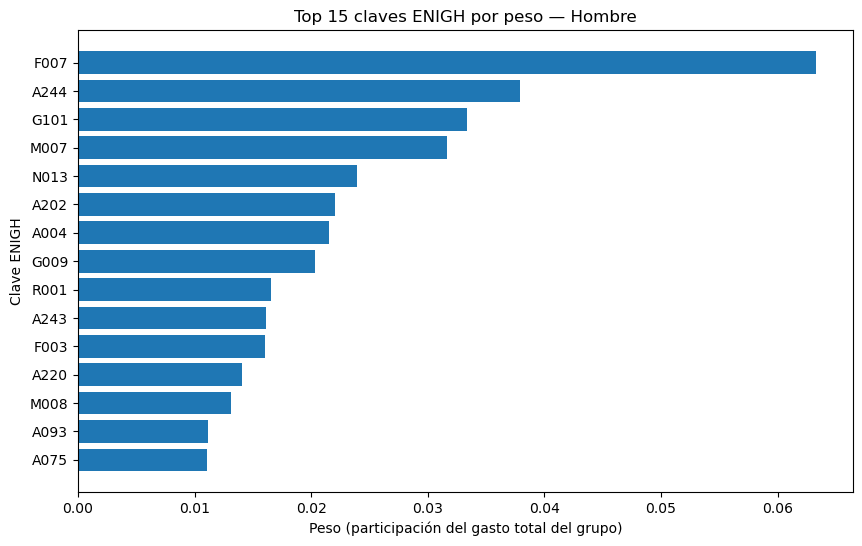

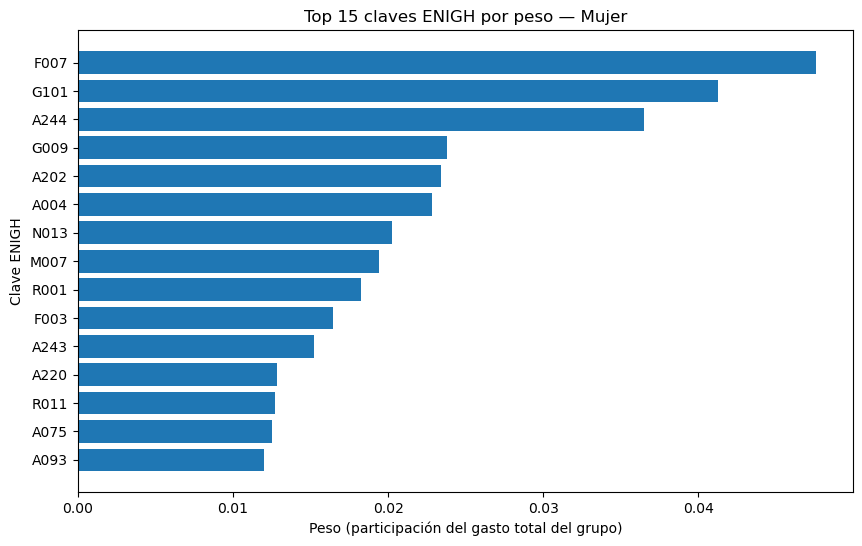

In [11]:
import matplotlib.pyplot as plt

# asegúrate que ponderadores existe (tu df: grupo, clave, peso)
top_n = 15

for g in ["Hombre", "Mujer"]:
    sub = (
        ponderadores[ponderadores["grupo"] == g]
        .sort_values("peso", ascending=False)
        .head(top_n)
        .sort_values("peso", ascending=True)
    )
    plt.figure(figsize=(10, 6))
    plt.barh(sub["clave"], sub["peso"])
    plt.xlabel("Peso (participación del gasto total del grupo)")
    plt.ylabel("Clave ENIGH")
    plt.title(f"Top {top_n} claves ENIGH por peso — {g}")
    plt.show()


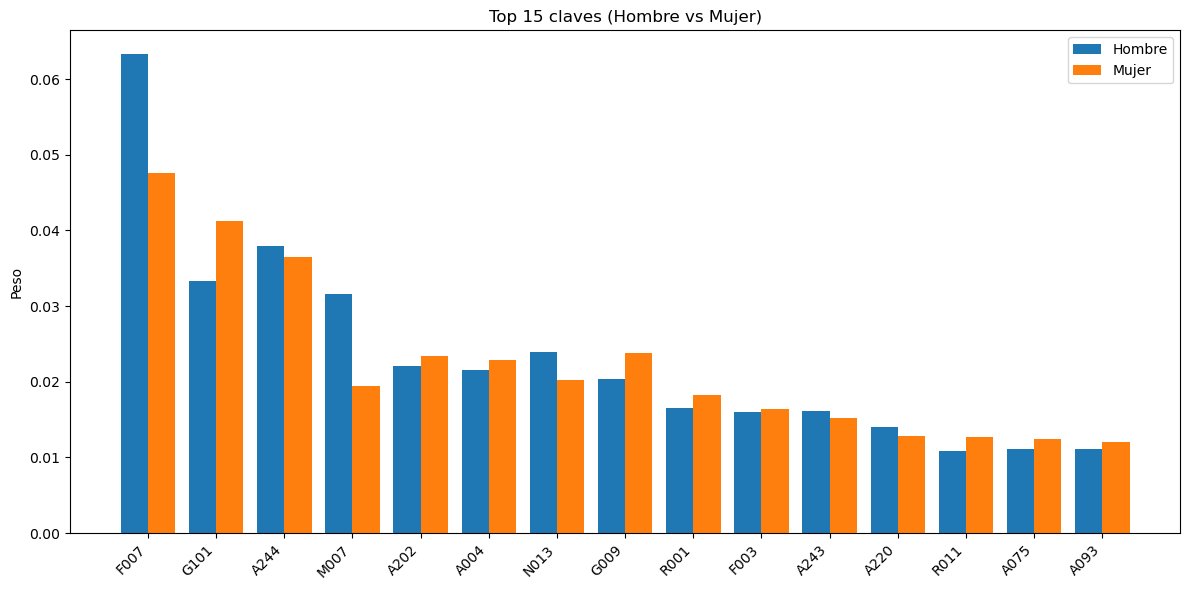

In [12]:
import numpy as np
import matplotlib.pyplot as plt

top_n = 15

pivot = ponderadores.pivot_table(index="clave", columns="grupo", values="peso", aggfunc="sum").fillna(0)

# top conjunto por suma de pesos (H+M)
top = pivot.assign(total=pivot.sum(axis=1)).sort_values("total", ascending=False).head(top_n).drop(columns="total")

labels = top.index.tolist()
x = np.arange(len(labels))

plt.figure(figsize=(12, 6))
plt.bar(x - 0.2, top.get("Hombre", 0), width=0.4, label="Hombre")
plt.bar(x + 0.2, top.get("Mujer", 0), width=0.4, label="Mujer")

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Peso")
plt.title(f"Top {top_n} claves (Hombre vs Mujer)")
plt.legend()
plt.tight_layout()
plt.show()


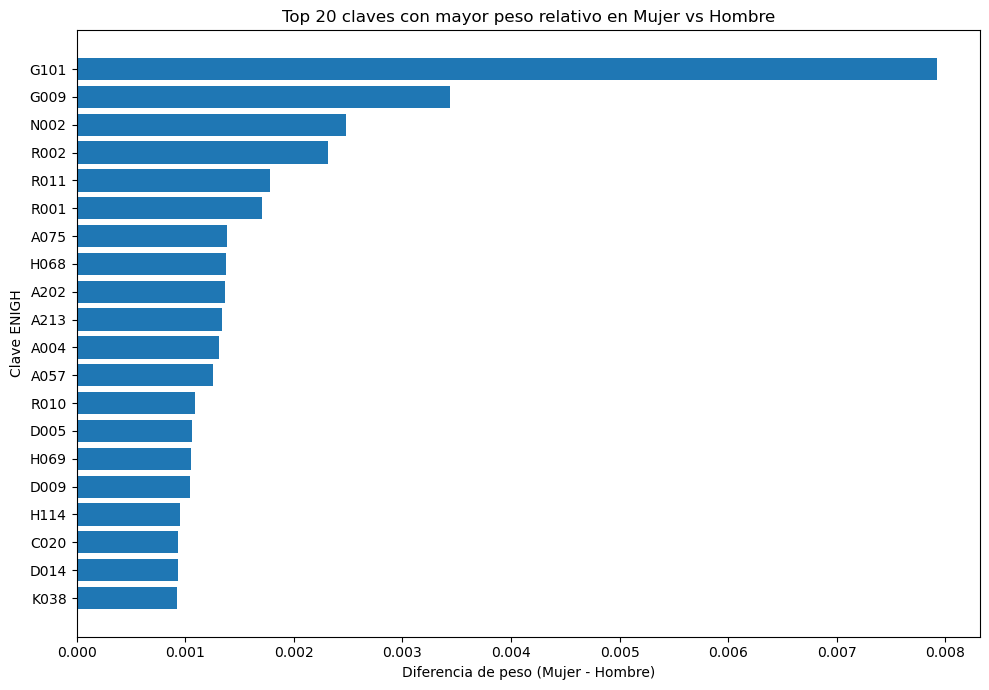

In [13]:
import matplotlib.pyplot as plt

pivot = ponderadores.pivot_table(index="clave", columns="grupo", values="peso", aggfunc="sum").fillna(0)
pivot["diff_mujer_menos_hombre"] = pivot.get("Mujer", 0) - pivot.get("Hombre", 0)

top_n = 20
sub = pivot.sort_values("diff_mujer_menos_hombre", ascending=False).head(top_n)
sub = sub.sort_values("diff_mujer_menos_hombre", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(sub.index, sub["diff_mujer_menos_hombre"])
plt.xlabel("Diferencia de peso (Mujer - Hombre)")
plt.ylabel("Clave ENIGH")
plt.title(f"Top {top_n} claves con mayor peso relativo en Mujer vs Hombre")
plt.tight_layout()
plt.show()


In [14]:
#REEMPLAZAR CLAVE POR DESCRIPCION
import pandas as pd

def add_enigh_label(df: pd.DataFrame, dic: pd.DataFrame, clave_col: str = "clave",
                    desc_col: str = "descripcion", out_col: str = "clave_label",
                    replace: bool = False) -> pd.DataFrame:
    """
    Adds a label column with 'CLAVE — descripción' using dic (clave->descripcion).
    If replace=True, overwrites clave_col with that label (not recommended for merges).
    """
    d = dic[[clave_col, desc_col]].drop_duplicates(clave_col).copy()
    d[clave_col] = d[clave_col].astype("string").str.strip()
    d[desc_col] = d[desc_col].astype("string").str.strip()

    out = df.copy()
    out[clave_col] = out[clave_col].astype("string").str.strip()

    out = out.merge(d, on=clave_col, how="left")
    out[out_col] = out[clave_col] + " — " + out[desc_col].fillna("")

    if replace:
        out[clave_col] = out[out_col]
        out = out.drop(columns=[desc_col, out_col], errors="ignore")
    return out


In [15]:
#PONDERADORES
ponderadores_l = add_enigh_label(ponderadores, dic_all, out_col="clave_label")
ponderadores_l.head(10)


,grupo,clave,peso,descripcion,clave_label
0,Hombre,F007,0.063283,Gasolina Magna,F007 — Gasolina Magna
1,Hombre,A244,0.037925,Comida,A244 — Comida
2,Hombre,G101,0.033368,Renta o alquiler de la vivienda,G101 — Renta o alquiler de la vivienda
3,Hombre,M007,0.031621,Automóvil y/o guayín,M007 — Automóvil y/o guayín
4,Hombre,N013,0.023939,"Ayuda a parientes y personas ajenas al hogar, ...",N013 — Ayuda a parientes y personas ajenas al ...
5,Hombre,A202,0.022035,"Otros alimentos preparados: atole, flautas, gu...","A202 — Otros alimentos preparados: atole, flau..."
6,Hombre,A004,0.021498,Tortilla de maíz (de todo tipo y color),A004 — Tortilla de maíz (de todo tipo y color)
7,Hombre,G009,0.020328,Gas licuado de petróleo,G009 — Gas licuado de petróleo
8,Hombre,R001,0.016517,Energía eléctrica,R001 — Energía eléctrica
9,Hombre,A243,0.016129,Desayuno,A243 — Desayuno


In [16]:
#PIVOT PARA GRAFICAS COMPARATIVAS ENTRE HOMBRE Y MUJER
pivot = ponderadores.pivot_table(index="clave", columns="grupo", values="peso", aggfunc="sum").reset_index()
pivot_l = add_enigh_label(pivot, dic_all, out_col="clave_label")
pivot_l.head()


,clave,Hombre,Mujer,descripcion,clave_label
0,A001,0.001302,0.001071,Maíz en grano (de todo tipo y color),A001 — Maíz en grano (de todo tipo y color)
1,A002,0.000566,0.000423,"Harina de maíz, maicena, fécula, nixtamalizada...","A002 — Harina de maíz, maicena, fécula, nixtam..."
2,A003,0.000967,0.000998,Masa de maíz (de todo tipo y color),A003 — Masa de maíz (de todo tipo y color)
3,A004,0.021498,0.022809,Tortilla de maíz (de todo tipo y color),A004 — Tortilla de maíz (de todo tipo y color)
4,A005,0.001117,0.001300,"Tostadas, raspadas, tostitos, totopos, tlayudas","A005 — Tostadas, raspadas, tostitos, totopos, ..."


In [17]:
#ETIQUETAS CORTAS
import re

def short_label(desc: str, n_words: int = 1) -> str:
    if desc is None:
        return ""
    desc = re.sub(r"\s+", " ", str(desc)).strip()
    words = desc.split()
    return " ".join(words[:n_words])

# agrega label corto a tu tabla con nombres
ponderadores_l = ponderadores.merge(dic_all, on="clave", how="left")
ponderadores_l["short1"] = ponderadores_l["descripcion"].apply(lambda x: short_label(x, 1))
ponderadores_l["short2"] = ponderadores_l["descripcion"].apply(lambda x: short_label(x, 2))
ponderadores_l["short3"] = ponderadores_l["descripcion"].apply(lambda x: short_label(x, 3))

# te recomiendo mantener la clave para evitar colisiones ("Maíz" puede repetirse)
ponderadores_l["label1"] = ponderadores_l["clave"] + " — " + ponderadores_l["short1"]
ponderadores_l["label2"] = ponderadores_l["clave"] + " — " + ponderadores_l["short2"]
ponderadores_l["label3"] = ponderadores_l["clave"] + " — " + ponderadores_l["short3"]


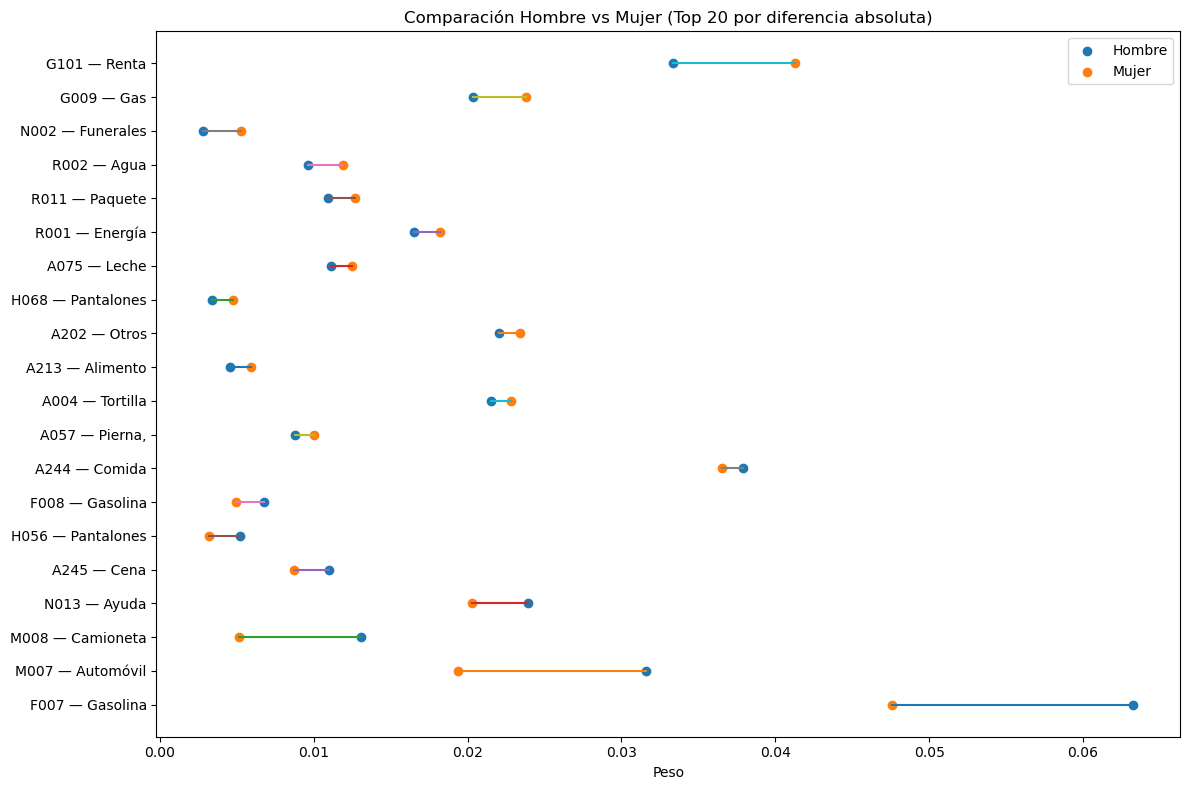

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

pivot = ponderadores.pivot_table(index="clave", columns="grupo", values="peso", aggfunc="sum").fillna(0).reset_index()
pivot = pivot.merge(dic_all, on="clave", how="left")
pivot["label"] = pivot["clave"] + " — " + pivot["descripcion"].apply(lambda x: short_label(x, 1))

pivot["diff"] = pivot.get("Mujer", 0) - pivot.get("Hombre", 0)
top_n = 20
sub = pivot.reindex(pivot["diff"].abs().sort_values(ascending=False).head(top_n).index).copy()
sub = sub.sort_values("diff")  # ordena para que se lea bien

plt.figure(figsize=(12, 8))
y = range(len(sub))

# líneas
for i, row in enumerate(sub.itertuples(index=False)):
    h = getattr(row, "Hombre", 0)
    m = getattr(row, "Mujer", 0)
    plt.plot([h, m], [i, i])

# puntos
plt.scatter(sub.get("Hombre", 0), list(y), label="Hombre")
plt.scatter(sub.get("Mujer", 0), list(y), label="Mujer")

plt.yticks(list(y), sub["label"])
plt.xlabel("Peso")
plt.title(f"Comparación Hombre vs Mujer (Top {top_n} por diferencia absoluta)")
plt.legend()
plt.tight_layout()
plt.show()
#DUMBBELL

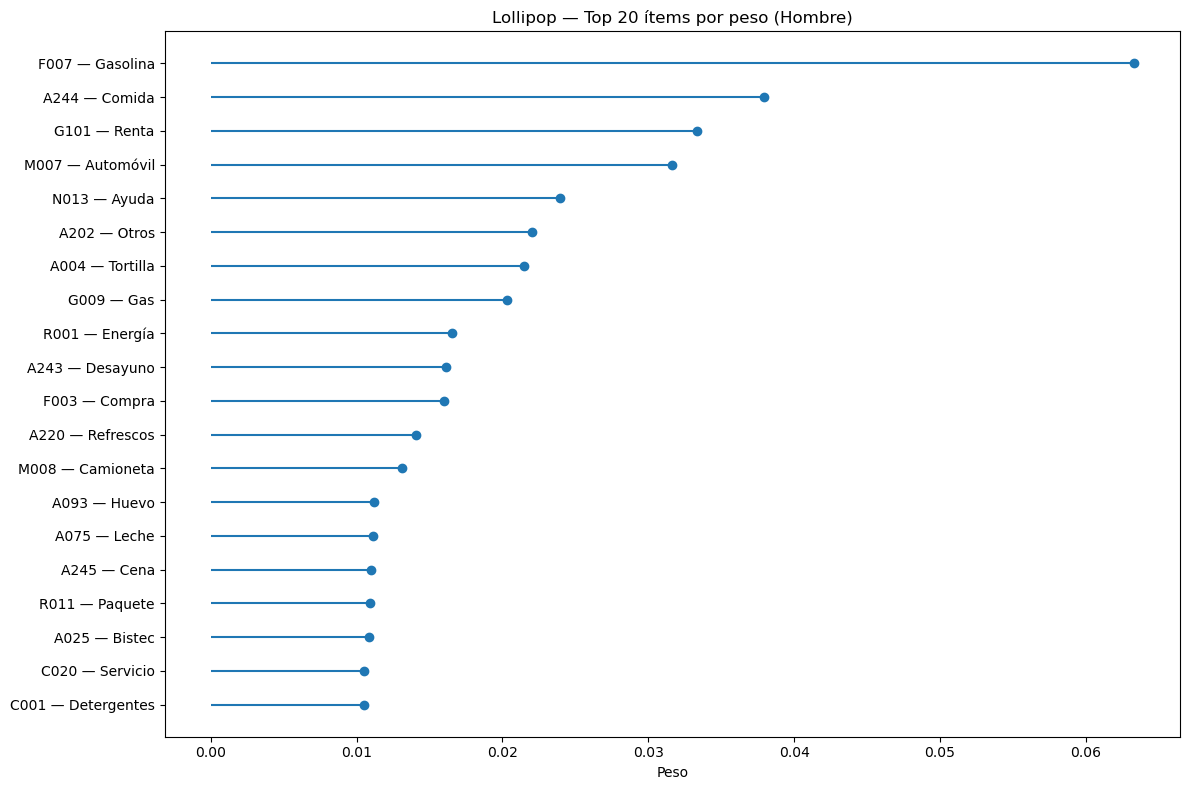

In [19]:
#LOLIPOP CHART
import matplotlib.pyplot as plt

g = "Hombre"
top_n = 20

sub = (
    ponderadores_l[ponderadores_l["grupo"] == g]
    .sort_values("peso", ascending=False)
    .head(top_n)
    .sort_values("peso", ascending=True)
)

labels = sub["label1"]  # usa label1 (clave + primera palabra)

plt.figure(figsize=(12, 8))
plt.hlines(y=range(len(sub)), xmin=0, xmax=sub["peso"])
plt.scatter(sub["peso"], range(len(sub)))
plt.yticks(range(len(sub)), labels)
plt.xlabel("Peso")
plt.title(f"Lollipop — Top {top_n} ítems por peso ({g})")
plt.tight_layout()
plt.show()


In [20]:
%pip install squarify


Note: you may need to restart the kernel to use updated packages.


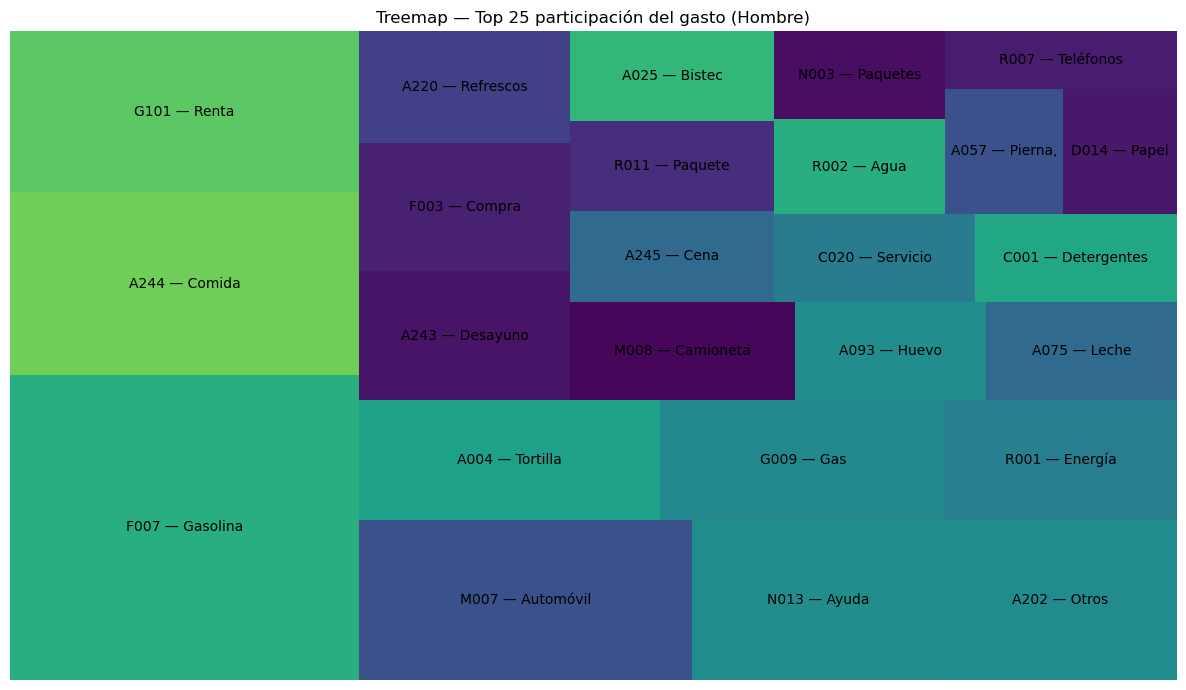

In [21]:
#TREEMAP
# pip install squarify  (si hace falta)
import matplotlib.pyplot as plt
import squarify

g = "Hombre"
top_n = 25

sub = (
    ponderadores_l[ponderadores_l["grupo"] == g]
    .sort_values("peso", ascending=False)
    .head(top_n)
    .copy()
)
sub["label"] = sub["label1"]  # clave + primera palabra

plt.figure(figsize=(12, 7))
squarify.plot(sizes=sub["peso"], label=sub["label"])
plt.axis("off")
plt.title(f"Treemap — Top {top_n} participación del gasto ({g})")
plt.tight_layout()
plt.show()


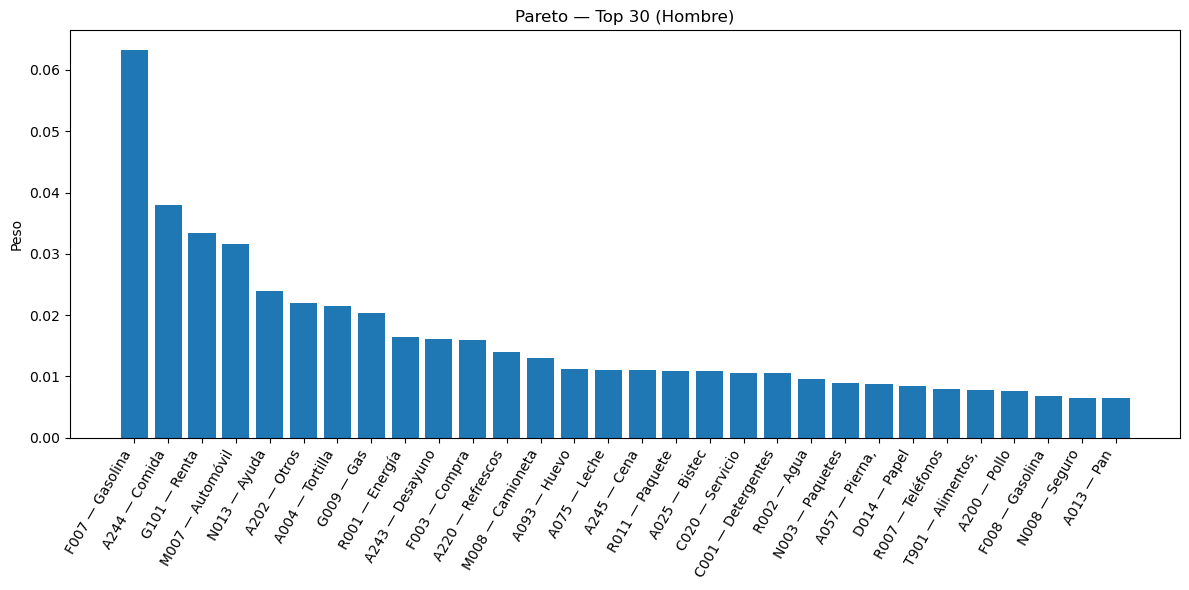

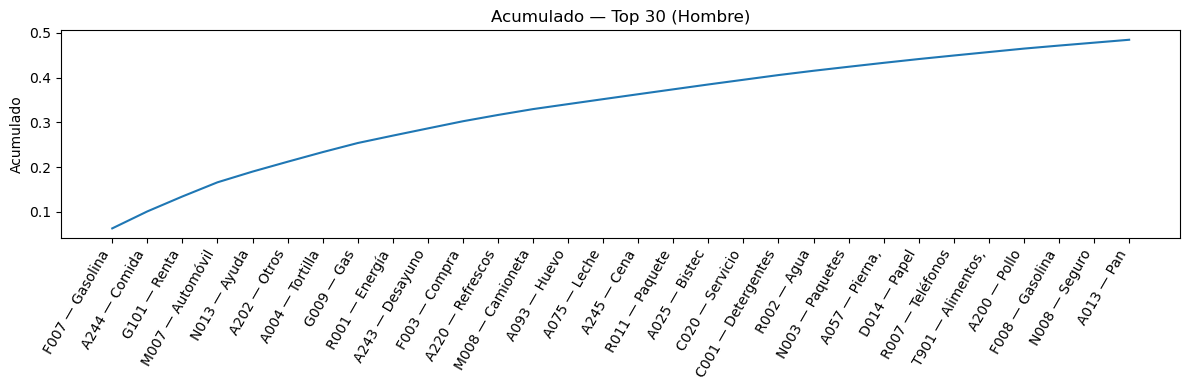

In [22]:
#PARETO
import numpy as np
import matplotlib.pyplot as plt

g = "Hombre"
top_n = 30

sub = (
    ponderadores_l[ponderadores_l["grupo"] == g]
    .sort_values("peso", ascending=False)
    .head(top_n)
    .copy()
)

sub["label"] = sub["clave"] + " — " + sub["descripcion"].apply(lambda x: str(x).split()[0] if pd.notna(x) else "")
sub["cum"] = sub["peso"].cumsum()

plt.figure(figsize=(12, 6))
plt.bar(range(len(sub)), sub["peso"])
plt.xticks(range(len(sub)), sub["label"], rotation=60, ha="right")
plt.ylabel("Peso")
plt.title(f"Pareto — Top {top_n} ({g})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(range(len(sub)), sub["cum"])
plt.xticks(range(len(sub)), sub["label"], rotation=60, ha="right")
plt.ylabel("Acumulado")
plt.title(f"Acumulado — Top {top_n} ({g})")
plt.tight_layout()
plt.show()


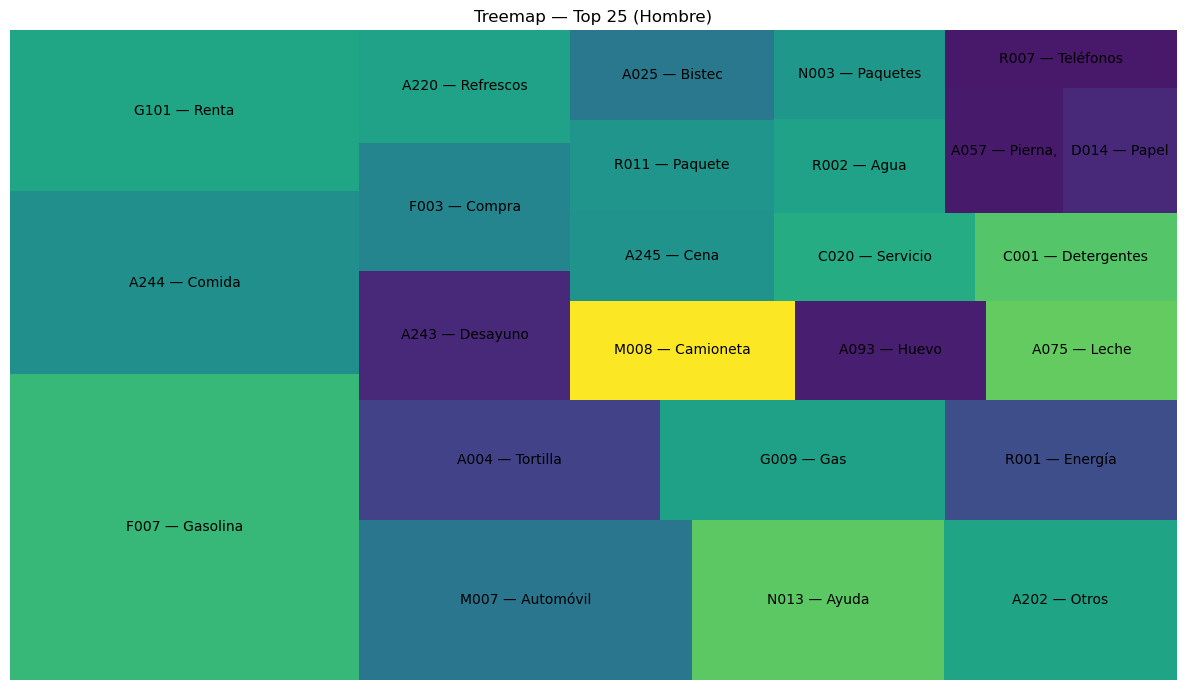

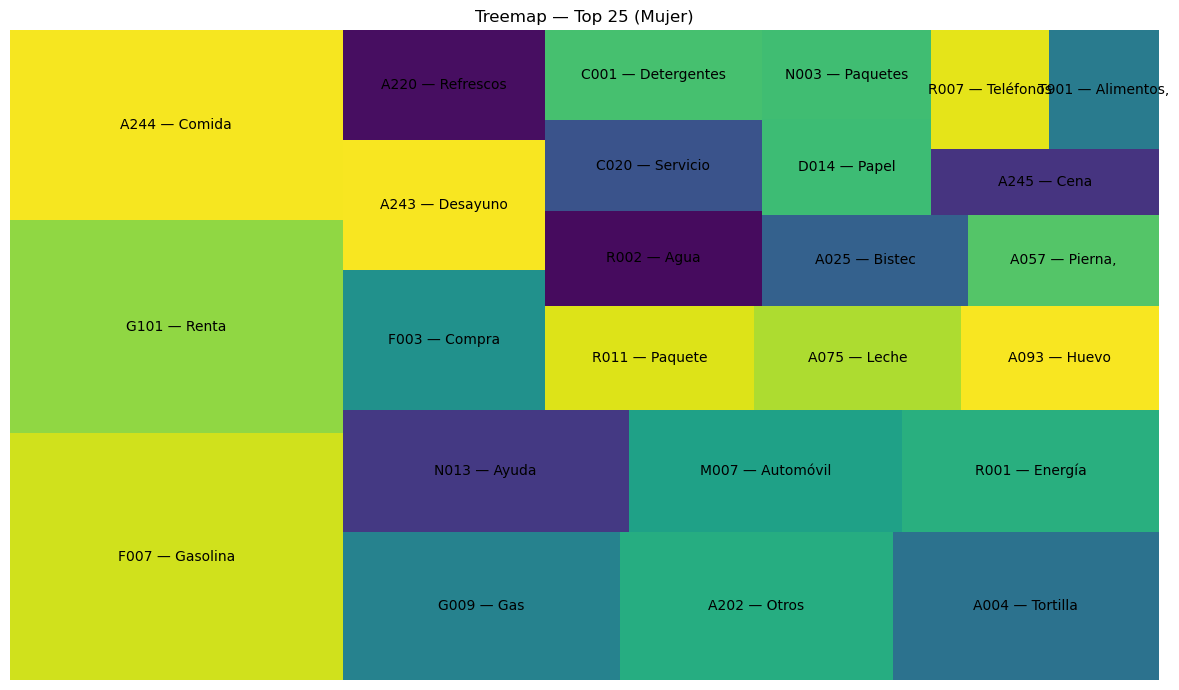

In [23]:
#TREEMAP PARA HOMBRE Y MUJER
# %pip install squarify
import matplotlib.pyplot as plt
import squarify
import pandas as pd

def treemap_top(df, grupo, top_n=25, label_col="label1"):
    sub = (
        df[df["grupo"] == grupo]
        .sort_values("peso", ascending=False)
        .head(top_n)
        .copy()
    )
    plt.figure(figsize=(12, 7))
    squarify.plot(sizes=sub["peso"], label=sub[label_col])
    plt.axis("off")
    plt.title(f"Treemap — Top {top_n} ({grupo})")
    plt.tight_layout()
    plt.show()

# Asegura ponderadores_l con labels (clave + primera palabra)
if "label1" not in ponderadores_l.columns:
    ponderadores_l["label1"] = ponderadores_l["clave"] + " — " + ponderadores_l["descripcion"].fillna("").astype(str).str.split().str[0]

treemap_top(ponderadores_l, "Hombre", top_n=25, label_col="label1")
treemap_top(ponderadores_l, "Mujer", top_n=25, label_col="label1")


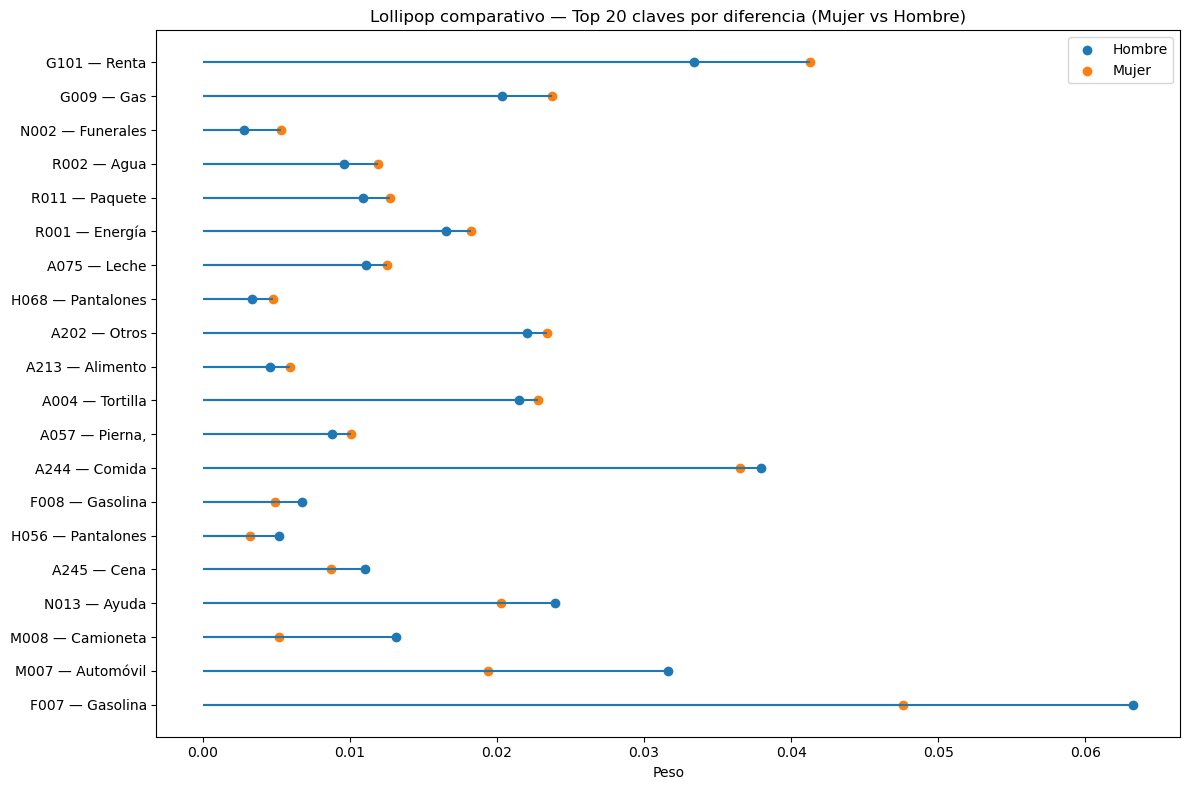

In [24]:
#LOLLIPOP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pivot Hombre/Mujer
pv = (
    ponderadores.pivot_table(index="clave", columns="grupo", values="peso", aggfunc="sum")
    .fillna(0)
    .reset_index()
)

pv = pv.merge(dic_all, on="clave", how="left")
pv["short1"] = pv["descripcion"].fillna("").astype(str).str.split().str[0]
pv["label"] = pv["clave"] + " — " + pv["short1"]

pv["diff"] = pv.get("Mujer", 0) - pv.get("Hombre", 0)

top_n = 20  # cambia a 15/25 si quieres
sub = pv.reindex(pv["diff"].abs().sort_values(ascending=False).head(top_n).index).copy()
sub = sub.sort_values("diff")  # orden para leer

y = np.arange(len(sub))

plt.figure(figsize=(12, 8))

# “palitos” (líneas desde 0 a cada punto)
plt.hlines(y, 0, sub.get("Hombre", 0), label=None)
plt.hlines(y, 0, sub.get("Mujer", 0), label=None)

# puntos: dos colores (matplotlib asigna colores por defecto)
plt.scatter(sub.get("Hombre", 0), y, label="Hombre")
plt.scatter(sub.get("Mujer", 0), y, label="Mujer")

plt.yticks(y, sub["label"])
plt.xlabel("Peso")
plt.title(f"Lollipop comparativo — Top {top_n} claves por diferencia (Mujer vs Hombre)")
plt.legend()
plt.tight_layout()
plt.show()


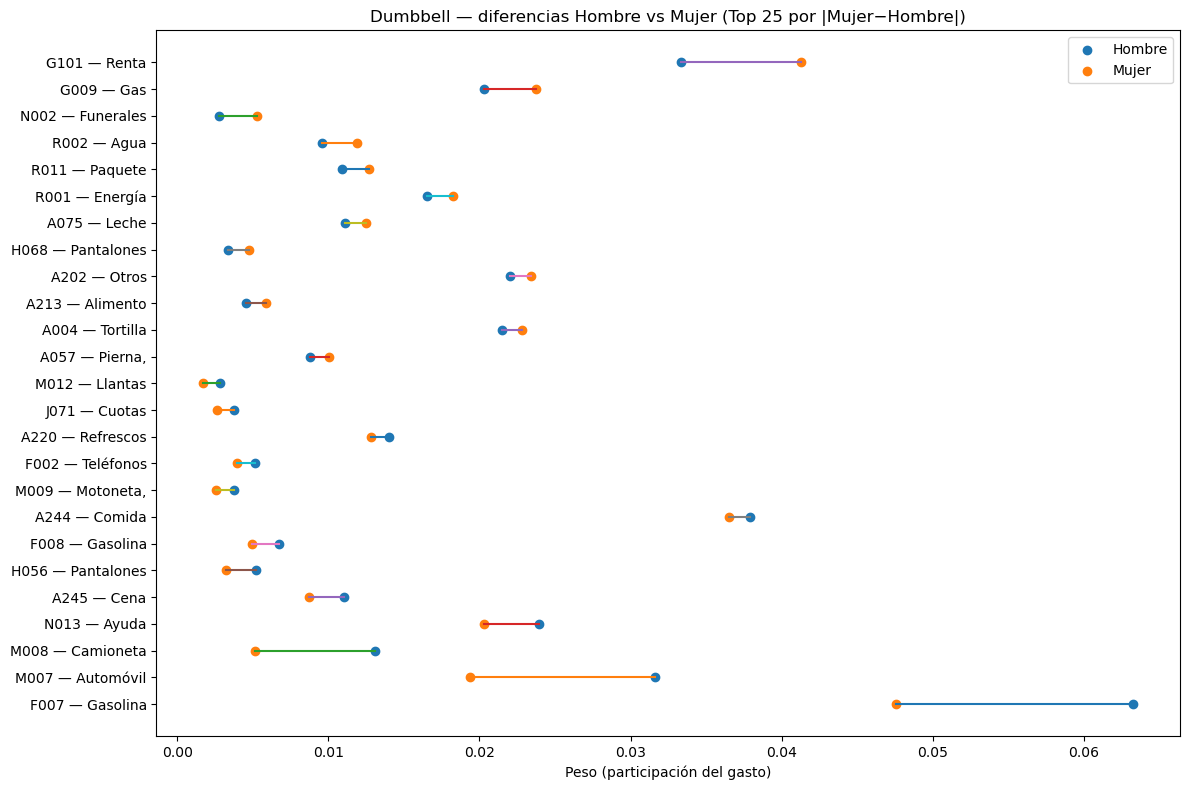

In [25]:
#Variante mejor (dumbbell) — aún más claro para diferencias

# Dumbbell chart (Hombre vs Mujer) — más claro para diferencias
# Requiere: ponderadores (grupo, clave, peso) y dic_all (clave, descripcion)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

def short_words(desc: str, n_words: int = 1) -> str:
    if desc is None or (isinstance(desc, float) and np.isnan(desc)):
        return ""
    desc = re.sub(r"\s+", " ", str(desc)).strip()
    parts = desc.split()
    return " ".join(parts[:n_words])

# 1) Pivot Hombre/Mujer
pv = (
    ponderadores.pivot_table(index="clave", columns="grupo", values="peso", aggfunc="sum")
    .fillna(0)
    .reset_index()
)

# 2) Añade descripción y etiqueta corta
pv = pv.merge(dic_all, on="clave", how="left")
pv["label"] = pv["clave"] + " — " + pv["descripcion"].apply(lambda x: short_words(x, 1))  # 1 palabra
# pv["label"] = pv["clave"] + " — " + pv["descripcion"].apply(lambda x: short_words(x, 2))  # 2 palabras

# 3) Elige qué mostrar: top por diferencia absoluta
pv["diff"] = pv.get("Mujer", 0) - pv.get("Hombre", 0)

top_n = 25  # cambia a 15/20/30
sub = pv.reindex(pv["diff"].abs().sort_values(ascending=False).head(top_n).index).copy()
sub = sub.sort_values("diff")  # orden para lectura

# 4) Plot dumbbell
y = np.arange(len(sub))
x_h = sub.get("Hombre", pd.Series([0]*len(sub))).to_numpy()
x_m = sub.get("Mujer", pd.Series([0]*len(sub))).to_numpy()

plt.figure(figsize=(12, 8))

# línea conectando Hombre-Mujer por ítem
for i in range(len(sub)):
    plt.plot([x_h[i], x_m[i]], [y[i], y[i]])

# puntos
plt.scatter(x_h, y, label="Hombre")
plt.scatter(x_m, y, label="Mujer")

plt.yticks(y, sub["label"])
plt.xlabel("Peso (participación del gasto)")
plt.title(f"Dumbbell — diferencias Hombre vs Mujer (Top {top_n} por |Mujer−Hombre|)")
plt.legend()
plt.tight_layout()
plt.show()


In [26]:
#CREAR CROSSWALK COICOP & ENIGH
from pathlib import Path
import pandas as pd

ENIGH_DIR = Path(r"D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E")
OUT_DIR = ENIGH_DIR / "03_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# claves observadas (de tus ponderadores o de gastoshogar)
claves_obs = pd.read_csv(OUT_DIR / "ponderadores_por_grupo.csv", dtype={"clave":"string"})[["clave"]].drop_duplicates()
plantilla = claves_obs.merge(dic_all, on="clave", how="left").rename(columns={"descripcion":"descripcion_enigh"})
plantilla["coicop_div"] = pd.NA      # 01..12
plantilla["coicop_div_nombre"] = pd.NA

plantilla.to_csv(OUT_DIR / "enigh_clave_to_coicop2018.csv", index=False)
plantilla.head()


,clave,descripcion_enigh,coicop_div,coicop_div_nombre
0,F007,Gasolina Magna,<NA>,<NA>
1,A244,Comida,<NA>,<NA>
2,G101,Renta o alquiler de la vivienda,<NA>,<NA>
3,M007,Automóvil y/o guayín,<NA>,<NA>
4,N013,"Ayuda a parientes y personas ajenas al hogar, ...",<NA>,<NA>


In [27]:
#VERIFICA SI EL ARCHIVO SE GUARDO Y DONDE
from pathlib import Path
import pandas as pd

ENIGH_DIR = Path(r"D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E")
OUT_DIR = ENIGH_DIR / "03_outputs"

path = OUT_DIR / "enigh_clave_to_coicop2018.csv"
print("Existe?", path.exists())
print("Ruta:", path)

df = pd.read_csv(path, dtype={"clave":"string"})
print("Filas:", len(df))
df.head(10)


Existe? True
Ruta: D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E\03_outputs\enigh_clave_to_coicop2018.csv
Filas: 755


,clave,descripcion_enigh,coicop_div,coicop_div_nombre
0,F007,Gasolina Magna,NaN,NaN
1,A244,Comida,NaN,NaN
2,G101,Renta o alquiler de la vivienda,NaN,NaN
3,M007,Automóvil y/o guayín,NaN,NaN
4,N013,"Ayuda a parientes y personas ajenas al hogar, ...",NaN,NaN
5,A202,"Otros alimentos preparados: atole, flautas, gu...",NaN,NaN
6,A004,Tortilla de maíz (de todo tipo y color),NaN,NaN
7,G009,Gas licuado de petróleo,NaN,NaN
8,R001,Energía eléctrica,NaN,NaN
9,A243,Desayuno,NaN,NaN


In [28]:
import re
import pandas as pd
from pathlib import Path

ENIGH_DIR = Path(r"D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E")
OUT_DIR = ENIGH_DIR / "03_outputs"

cw = pd.read_csv(OUT_DIR / "enigh_clave_to_coicop2018.csv", dtype={"clave":"string"})

def norm_text(s: str) -> str:
    s = "" if s is None else str(s)
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

# 1) Overrides (prioridad máxima) — aquí metemos "fiesta" / "orquesta" / "salón"
OVERRIDES = [
    ("09", "Recreación y cultura", r"\b(fiesta|orquesta|dj|musica en vivo|sal[oó]n de eventos|banquete|evento)\b"),
    ("11", "Restaurantes y hoteles", r"\b(catering|servicio de comida|comida para evento)\b"),
]

# 2) Reglas generales (en orden de prioridad)
RULES = [
    ("12", "Bienes y servicios diversos", r"\b(ayuda|donativo|remesa|transferenc|funeral|servicio doméstico|emplead[oa])\b"),
    ("08", "Comunicación", r"\b(teléfono|internet|recarga|celular)\b"),
    ("07", "Transporte", r"\b(gasolina|automóvil|camioneta|llanta|taxi|autobús|metro|pasaje|transporte)\b"),
    ("06", "Salud", r"\b(medic|doctor|consulta|hospital|farmacia)\b"),
    ("04", "Vivienda, agua, electricidad, gas y otros combustibles", r"\b(renta|alquiler|agua|luz|electricidad|gas)\b"),
    ("05", "Muebles y mantenimiento del hogar", r"\b(mueble|silla|mesa|refrigerador|estufa|lavadora|detergente|limpieza)\b"),
    ("03", "Vestido y calzado", r"\b(calzado|zapato|tenis|pantal[oó]n|playera|camisa|ropa|falda|vestido)\b"),
    ("10", "Educación", r"\b(colegiatura|inscripci[oó]n|escuela|[uú]tiles|uniforme)\b"),
    ("09", "Recreación y cultura", r"\b(cine|teatro|juguete|deporte|turis|vacaciones)\b"),
    ("11", "Restaurantes y hoteles", r"\b(restaurante|hotel|comida\s+fuera|desayuno|cena)\b"),
    ("02", "Bebidas alcohólicas y tabaco", r"\b(cerveza|vino|licor|tabaco|cigarro)\b"),
    ("01", "Alimentos y bebidas no alcohólicas", r"\b(tortilla|pan|leche|huevo|carne|pollo|pescad|fruta|verdura|arroz|frijol|cereal|az[uú]car|refresco)\b"),
]

def suggest_div(desc: str):
    t = norm_text(desc)
    if not t:
        return (pd.NA, pd.NA, "SIN_TEXTO")

    # overrides
    for div, name, pat in OVERRIDES:
        if re.search(pat, t):
            return (div, name, "OVERRIDE")

    # scoring: detecta si matchea múltiples reglas
    matches = []
    for div, name, pat in RULES:
        if re.search(pat, t):
            matches.append((div, name))
    if len(matches) == 0:
        return (pd.NA, pd.NA, "SIN_MATCH")
    if len(matches) > 1:
        # ambigua: no adivinamos, mejor revisar manual
        return (pd.NA, pd.NA, f"AMBIGUA:{','.join(sorted(set([m[0] for m in matches])))}")

    return (matches[0][0], matches[0][1], "REGLA")

tmp = cw["descripcion_enigh"].apply(suggest_div)
cw["coicop_div_sugerida"] = tmp.apply(lambda x: x[0])
cw["coicop_div_nombre_sugerida"] = tmp.apply(lambda x: x[1])
cw["sugerencia_tipo"] = tmp.apply(lambda x: x[2])

out = OUT_DIR / "enigh_clave_to_coicop2018_con_sugerencias_v3.csv"
cw.to_csv(out, index=False)
print("Guardado:", out)

cw[["clave","descripcion_enigh","coicop_div_sugerida","coicop_div_nombre_sugerida","sugerencia_tipo"]].head(30)


Guardado: D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E\03_outputs\enigh_clave_to_coicop2018_con_sugerencias_v3.csv


,clave,descripcion_enigh,coicop_div_sugerida,coicop_div_nombre_sugerida,sugerencia_tipo
0,F007,Gasolina Magna,07,Transporte,REGLA
1,A244,Comida,<NA>,<NA>,SIN_MATCH
2,G101,Renta o alquiler de la vivienda,04,"Vivienda, agua, electricidad, gas y otros comb...",REGLA
3,M007,Automóvil y/o guayín,07,Transporte,REGLA
4,N013,"Ayuda a parientes y personas ajenas al hogar, ...",<NA>,<NA>,"AMBIGUA:04,12"
5,A202,"Otros alimentos preparados: atole, flautas, gu...",<NA>,<NA>,SIN_MATCH
6,A004,Tortilla de maíz (de todo tipo y color),01,Alimentos y bebidas no alcohólicas,REGLA
7,G009,Gas licuado de petróleo,04,"Vivienda, agua, electricidad, gas y otros comb...",REGLA
8,R001,Energía eléctrica,<NA>,<NA>,SIN_MATCH
9,A243,Desayuno,11,Restaurantes y hoteles,REGLA


In [29]:
rev = cw[cw["coicop_div_sugerida"].isna()][["clave","descripcion_enigh","sugerencia_tipo"]].copy()
rev.to_csv(OUT_DIR / "crosswalk_para_revision.csv", index=False)
print("A revisar:", len(rev))
rev.head(30)


A revisar: 640


,clave,descripcion_enigh,sugerencia_tipo
1,A244,Comida,SIN_MATCH
4,N013,"Ayuda a parientes y personas ajenas al hogar, ...","AMBIGUA:04,12"
5,A202,"Otros alimentos preparados: atole, flautas, gu...",SIN_MATCH
8,R001,Energía eléctrica,SIN_MATCH
11,A220,Refrescos de cola y de sabores,SIN_MATCH
17,A025,Bistec de res (de cualquier parte que se saque),SIN_MATCH
19,C001,"Detergentes (polvo, líquido, pasta, gel)",SIN_MATCH
23,D014,"Papel sanitario, pañuelos desechables",SIN_MATCH
24,R007,Teléfonos celulares (plan mensual),SIN_MATCH
30,A124,Jitomate,SIN_MATCH


In [30]:
#NORMALIZAR TEXTO, SIN ACENTOS
import re
import pandas as pd
import unicodedata
from pathlib import Path

ENIGH_DIR = Path(r"D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E")
OUT_DIR = ENIGH_DIR / "03_outputs"
cw = pd.read_csv(OUT_DIR / "enigh_clave_to_coicop2018.csv", dtype={"clave":"string"})

def strip_accents(s: str) -> str:
    s = "" if s is None else str(s)
    return "".join(ch for ch in unicodedata.normalize("NFKD", s) if not unicodedata.combining(ch))

def norm_text(s: str) -> str:
    s = strip_accents(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

# Overrides (muy específicos)
OVERRIDES = [
    ("09", "Recreacion y cultura", r"\b(fiesta|orquesta|dj|musica en vivo|salon de eventos|banquete|evento)\b"),
    ("11", "Restaurantes y hoteles", r"\b(catering|servicio de comida|comida para evento)\b"),
]

# Reglas generales (con MUCHOS más keywords)
RULES = [
    # 12: diversos / seguros / cuidado personal / higiene / pañales / mascotas
    ("12", "Bienes y servicios diversos",
     r"\b(ayuda|donativo|remesa|transferenc|funeral|seguro|seguros|cuotas a companias de seguros|"
     r"corte de cabello|peinado|peluquer|locion|perfume|desodorante|talco|shampu|shampoo|enjuague|"
     r"pasta dental|enjuague bucal|jabon de tocador|panales|pañales|alimento para animales|mascot)\b"),

    # 11: restaurantes/hoteles/turismo (paquetes, hospedaje, alimentos fuera)
    ("11", "Restaurantes y hoteles",
     r"\b(restaurante|hotel|hospedaj|comida fuera|desayuno|cena|gastos turistic|paquetes turistic)\b"),

    # 10: educación
    ("10", "Educacion", r"\b(colegiatura|inscripcion|escuela|utiles|uniforme)\b"),

    # 09: recreación/cultura (si no cae en 11 por hospedaje)
    ("09", "Recreacion y cultura", r"\b(cine|teatro|juguete|deporte|recreac|cultura)\b"),

    # 08: comunicación (internet/telefonía/tv paga)
    ("08", "Comunicacion",
     r"\b(telefono|telefonos|celular|celulares|recarga|internet|paquete de internet|television de paga|tv de paga|plan mensual)\b"),

    # 07: transporte (gasolina, vehículo, llantas, motoneta)
    ("07", "Transporte",
     r"\b(gasolina|automovil|camioneta|pickup|llanta|llantas|motoneta|motocicleta|taxi|autobus|metro|pasaje|transporte)\b"),

    # 06: salud (hospitalización)
    ("06", "Salud",
     r"\b(hospitalizacion|hospitalizacion|hospital|consulta|doctor|farmacia|medic)\b"),

    # 05: hogar / limpieza / papel sanitario / detergentes / suavizantes
    ("05", "Muebles, articulos para el hogar y mantenimiento",
     r"\b(detergent|suavizante|limpieza|papel sanitario|panuelos desechables|pañuelos desechables)\b"),

    # 04: vivienda/servicios (renta, agua, electricidad, gas, energia electrica)
    ("04", "Vivienda, agua, electricidad, gas y otros combustibles",
     r"\b(renta|alquiler|agua|luz|electricidad|energia electrica|gas)\b"),

    # 03: vestido y calzado (pantalones)
    ("03", "Vestido y calzado",
     r"\b(pantalon|pantalones|playera|camisa|ropa|falda|vestido|calzado|zapato|tenis)\b"),

    # 02: alcohol/tabaco
    ("02", "Bebidas alcoholicas y tabaco", r"\b(cerveza|vino|licor|tabaco|cigarro)\b"),

    # 01: alimentos (refrescos, jitomate, bistec, molida, aceite, etc.)
    ("01", "Alimentos y bebidas no alcoholicas",
     r"\b(tortilla|pan|leche|huevo|carne|pollo|pescad|fruta|verdura|jitomate|arroz|frijol|cereal|"
     r"azucar|refresco|refrescos|bistec|molida|aceite vegetal|aceite)\b"),
]

def suggest_div(desc: str):
    t = norm_text(desc)
    if not t:
        return (pd.NA, pd.NA, "SIN_TEXTO")

    for div, name, pat in OVERRIDES:
        if re.search(pat, t):
            return (div, name, "OVERRIDE")

    matches = []
    for div, name, pat in RULES:
        if re.search(pat, t):
            matches.append((div, name))

    if len(matches) == 0:
        return (pd.NA, pd.NA, "SIN_MATCH")
    if len(matches) > 1:
        return (pd.NA, pd.NA, f"AMBIGUA:{','.join(sorted({m[0] for m in matches}))}")

    return (matches[0][0], matches[0][1], "REGLA")

tmp = cw["descripcion_enigh"].apply(suggest_div)
cw["coicop_div_sugerida"] = tmp.apply(lambda x: x[0])
cw["coicop_div_nombre_sugerida"] = tmp.apply(lambda x: x[1])
cw["sugerencia_tipo"] = tmp.apply(lambda x: x[2])

out = OUT_DIR / "enigh_clave_to_coicop2018_con_sugerencias_v4.csv"
cw.to_csv(out, index=False)

print("Guardado:", out)
print("SIN_MATCH:", int((cw["sugerencia_tipo"] == "SIN_MATCH").sum()))
print("AMBIGUA:", int(cw["sugerencia_tipo"].astype(str).str.startswith("AMBIGUA").sum()))

# muestra los que siguen sin match
cw.loc[cw["sugerencia_tipo"] == "SIN_MATCH", ["clave","descripcion_enigh","sugerencia_tipo"]].head(50)


Guardado: D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E\03_outputs\enigh_clave_to_coicop2018_con_sugerencias_v4.csv
SIN_MATCH: 599
AMBIGUA: 3


,clave,descripcion_enigh,sugerencia_tipo
1,A244,Comida,SIN_MATCH
5,A202,"Otros alimentos preparados: atole, flautas, gu...",SIN_MATCH
18,C020,Servicio doméstico,SIN_MATCH
19,C001,"Detergentes (polvo, líquido, pasta, gel)",SIN_MATCH
33,D005,"Champús, enjuagues, tratamiento para el cabello",SIN_MATCH
35,N004,"Gastos turísticos: paquetes, hospedajes, alime...",SIN_MATCH
38,D002,Lociones y perfumes,SIN_MATCH
43,C004,Suavizantes de telas,SIN_MATCH
47,K040,"Materiales para ampliación, construcción y rem...",SIN_MATCH
55,K038,Materiales para reparación y mantenimiento,SIN_MATCH


In [31]:
#DEBUG PRUEB
import re, unicodedata, pandas as pd

def strip_accents(s: str) -> str:
    s = "" if s is None else str(s)
    return "".join(ch for ch in unicodedata.normalize("NFKD", s) if not unicodedata.combining(ch))

def norm_text(s: str) -> str:
    s = strip_accents(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

tests = [
    "Detergentes (polvo, líquido, pasta, gel)",
    "Champús, enjuagues, tratamiento para el cabello",
    "Servicio doméstico",
    "Gastos turísticos: paquetes, hospedajes, alimentos",
    "Comida",
]

patterns = {
    "detergent": r"detergent",
    "shampu": r"shampu|shampoo|champus",
    "domestico": r"servicio domestico|domestic",
    "turismo": r"gastos turistic|paquetes turistic|hospedaj|hotel",
    "comida_fuera": r"comida fuera|restaurante|cena|desayuno|entrecomidas",
    "comida_simple": r"comida",
}

for t in tests:
    nt = norm_text(t)
    print("\nRAW:", t)
    print("NORM:", nt)
    for k, p in patterns.items():
        print(k, bool(re.search(p, nt)))



RAW: Detergentes (polvo, líquido, pasta, gel)
NORM: detergentes (polvo, liquido, pasta, gel)
detergent True
shampu False
domestico False
turismo False
comida_fuera False
comida_simple False

RAW: Champús, enjuagues, tratamiento para el cabello
NORM: champus, enjuagues, tratamiento para el cabello
detergent False
shampu True
domestico False
turismo False
comida_fuera False
comida_simple False

RAW: Servicio doméstico
NORM: servicio domestico
detergent False
shampu False
domestico True
turismo False
comida_fuera False
comida_simple False

RAW: Gastos turísticos: paquetes, hospedajes, alimentos
NORM: gastos turisticos: paquetes, hospedajes, alimentos
detergent False
shampu False
domestico False
turismo True
comida_fuera False
comida_simple False

RAW: Comida
NORM: comida
detergent False
shampu False
domestico False
turismo False
comida_fuera False
comida_simple True


In [32]:
import re
import pandas as pd
import unicodedata
from pathlib import Path

ENIGH_DIR = Path(r"D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E")
OUT_DIR = ENIGH_DIR / "03_outputs"

# Carga el crosswalk base (el que tiene clave + descripcion_enigh)
cw = pd.read_csv(OUT_DIR / "enigh_clave_to_coicop2018.csv", dtype={"clave":"string"})
cw["clave"] = cw["clave"].astype("string").str.strip()

def strip_accents(s: str) -> str:
    s = "" if s is None else str(s)
    return "".join(ch for ch in unicodedata.normalize("NFKD", s) if not unicodedata.combining(ch))

def norm_text(s: str) -> str:
    s = strip_accents(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

# Reglas mínimas SOLO para probar tus ejemplos
RULES = [
    ("05", "Hogar/limpieza", r"detergent|suavizante|limpiador|blanqueador|jabon"),
    ("12", "Diversos/personal", r"servicio domestico|champus|shampu|shampoo|perfume|locion|crema|toallas sanitarias|rastrill"),
    ("11", "Turismo/hotel/rest", r"gastos turistic|paquetes|hospedaj|hotel|comida fuera|restaurante|desayuno|cena|entrecomidas"),
    ("01", "Alimentos", r"comida|pizzas|papa|cebolla|chorizo|queso|manzana|galletas|aguacate|costilla|chuleta|carnitas|barbacoa|birria"),
    ("04", "Vivienda/servicios", r"energia electrica|electricidad|luz|gas|predial|materiales|construccion|remodel"),
    ("06", "Salud", r"consulta|hospitalizacion|medicamento|analisis|dent"),
    ("08", "Comunicacion", r"telefono|celular|television de paga|internet"),
    ("03", "Vestido", r"camisas|blusas|uniformes|prendas de vestir"),
    ("09", "Recreacion", r"cines|computadora|tabletas|television color"),
    ("07", "Transporte", r"afinacion|alineacion|balanceo|tenencia vehicular|gasolina|automovil|moto"),
]

def suggest(desc: str):
    t = norm_text(desc)
    for div, name, pat in RULES:
        if re.search(pat, t):
            return div, name, "OK"
    return pd.NA, pd.NA, "SIN_MATCH"

tmp = cw["descripcion_enigh"].apply(suggest)
cw["coicop_div_sugerida"] = tmp.apply(lambda x: x[0])
cw["coicop_div_nombre_sugerida"] = tmp.apply(lambda x: x[1])
cw["sugerencia_tipo"] = tmp.apply(lambda x: x[2])

# Verifica EXACTAMENTE tus filas problemáticas
ejemplos = ["C001","D005","C020","N004","A244"]
cw.loc[cw["clave"].isin(ejemplos), ["clave","descripcion_enigh","coicop_div_sugerida","coicop_div_nombre_sugerida","sugerencia_tipo"]]


,clave,descripcion_enigh,coicop_div_sugerida,coicop_div_nombre_sugerida,sugerencia_tipo
1,A244,Comida,01,Alimentos,OK
18,C020,Servicio doméstico,12,Diversos/personal,OK
19,C001,"Detergentes (polvo, líquido, pasta, gel)",05,Hogar/limpieza,OK
33,D005,"Champús, enjuagues, tratamiento para el cabello",12,Diversos/personal,OK
35,N004,"Gastos turísticos: paquetes, hospedajes, alime...",11,Turismo/hotel/rest,OK


In [33]:
out = OUT_DIR / "enigh_clave_to_coicop2018_con_sugerencias_OK.csv"
cw.to_csv(out, index=False)
print("Guardado:", out)


Guardado: D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E\03_outputs\enigh_clave_to_coicop2018_con_sugerencias_OK.csv


In [34]:
#ESTE ES EL CROSSWALK FINAL
import pandas as pd
from pathlib import Path

ENIGH_DIR = Path(r"D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E")
OUT_DIR = ENIGH_DIR / "03_outputs"

cw = pd.read_csv(OUT_DIR / "enigh_clave_to_coicop2018_con_sugerencias_OK.csv", dtype={"clave":"string"})

# crea columnas finales (para ya usarlo)
cw["coicop_div"] = cw["coicop_div_sugerida"]
cw["coicop_div_nombre"] = cw["coicop_div_nombre_sugerida"]

final_path = OUT_DIR / "enigh_clave_to_coicop2018_FINAL.csv"
cw[["clave","descripcion_enigh","coicop_div","coicop_div_nombre"]].to_csv(final_path, index=False)

print("FINAL guardado:", final_path)
print("Sin clasificar:", cw["coicop_div"].isna().sum())


FINAL guardado: D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E\03_outputs\enigh_clave_to_coicop2018_FINAL.csv
Sin clasificar: 576


In [35]:
dic_all.loc[dic_all["clave"].eq("A244")]


,clave,descripcion
243,A244,Comida


In [36]:
#Override directo (para fijar A244 en COICOP 11)
import pandas as pd
from pathlib import Path

ENIGH_DIR = Path(r"D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E")
OUT_DIR = ENIGH_DIR / "03_outputs"

cw = pd.read_csv(OUT_DIR / "enigh_clave_to_coicop2018_FINAL.csv", dtype={"clave":"string","coicop_div":"string"})
cw["clave"] = cw["clave"].str.strip()

# Fuerza comidas fuera a COICOP 11
override_11 = {"A243", "A244", "A245", "A246"}
mask = cw["clave"].isin(override_11)
cw.loc[mask, "coicop_div"] = "11"
cw.loc[mask, "coicop_div_nombre"] = "Restaurantes y hoteles"

out = OUT_DIR / "enigh_clave_to_coicop2018_FINAL.csv"
cw.to_csv(out, index=False)
print("Actualizado:", out)
cw.loc[cw["clave"].isin(sorted(override_11)), ["clave","descripcion_enigh","coicop_div","coicop_div_nombre"]]


Actualizado: D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E\03_outputs\enigh_clave_to_coicop2018_FINAL.csv


,clave,descripcion_enigh,coicop_div,coicop_div_nombre
1,A244,Comida,11,Restaurantes y hoteles
9,A243,Desayuno,11,Restaurantes y hoteles
15,A245,Cena,11,Restaurantes y hoteles
96,A246,Entrecomidas,11,Restaurantes y hoteles


Saved: D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E\03_outputs\ponderadores_coicop_div_por_sexo.csv


,grupo,coicop_div,coicop_div_nombre,wgasto,total,peso
5,Hombre,4.0,Vivienda/servicios,5.618742e+11,1.982447e+12,0.283425
1,Hombre,11,Restaurantes y hoteles,2.757478e+11,1.982447e+12,0.139095
9,Hombre,8.0,Comunicacion,2.232341e+11,1.982447e+12,0.112605
8,Hombre,7.0,Transporte,2.046103e+11,1.982447e+12,0.103211
0,Hombre,1.0,Alimentos,1.828708e+11,1.982447e+12,0.092245
7,Hombre,6.0,Salud,1.517526e+11,1.982447e+12,0.076548
3,Hombre,12.0,Diversos/personal,1.284531e+11,1.982447e+12,0.064795
6,Hombre,5.0,Hogar/limpieza,1.160285e+11,1.982447e+12,0.058528
2,Hombre,11.0,Turismo/hotel/rest,6.220733e+10,1.982447e+12,0.031379
4,Hombre,3.0,Vestido,4.349026e+10,1.982447e+12,0.021938


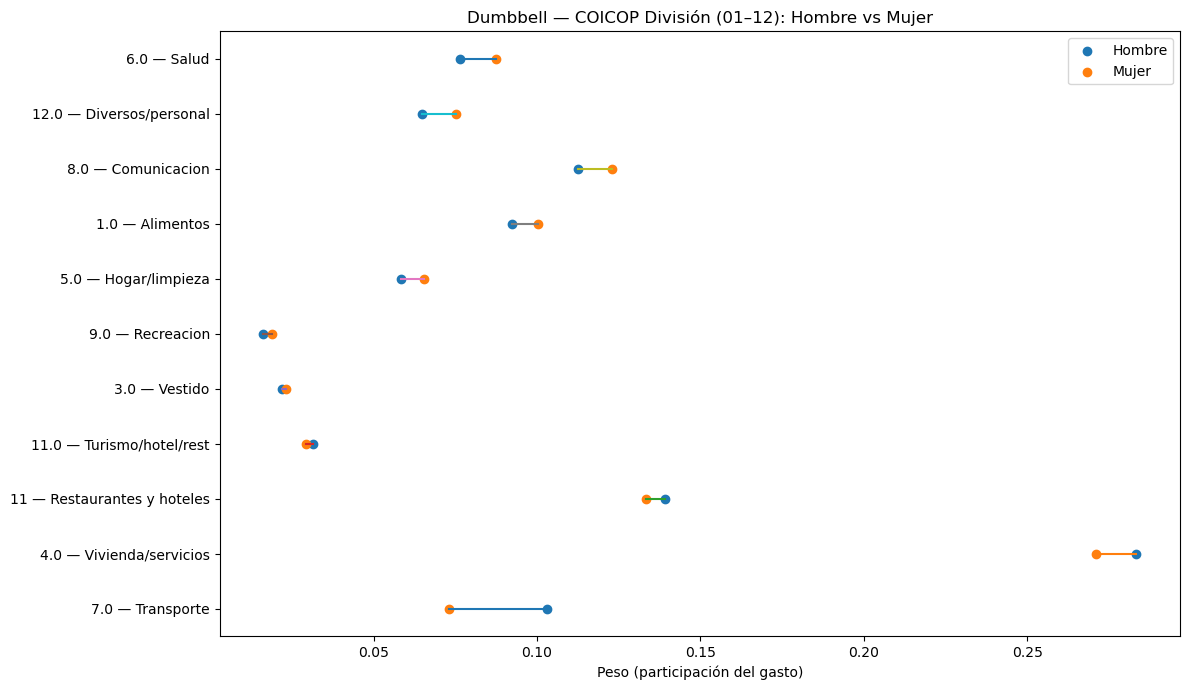

In [37]:
#: usar tu crosswalk FINAL para (1) ponderadores COICOP por sexo y (2) graficarlo (dumbbell) por división 01–12
# === 04_coicop_div_weights_and_dumbbell.ipynb ===
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ENIGH_DIR = Path(r"D:\Documents\ITZEL\Tesis\ENIGH_est 2022\ENIGH E")
OUT_DIR = ENIGH_DIR / "03_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Inputs
CROSSWALK = OUT_DIR / "enigh_clave_to_coicop2018_FINAL.csv"
GSH_PATH = ENIGH_DIR / "gastoshogar.csv"
CON_PATH = ENIGH_DIR / "concentradohogar.csv"

# --- Load
gsh = pd.read_csv(GSH_PATH, low_memory=False, dtype={"clave": "string"})
con = pd.read_csv(CON_PATH, low_memory=False)
cw = pd.read_csv(CROSSWALK, dtype={"clave": "string", "coicop_div": "string"})

# --- Clean
gsh["clave"] = gsh["clave"].astype("string").str.strip()
cw["clave"] = cw["clave"].astype("string").str.strip()
cw["coicop_div"] = cw["coicop_div"].astype("string").str.zfill(2)

sexo_map = {1: "Hombre", 2: "Mujer"}
con["grupo"] = pd.to_numeric(con.get("sexo_jefe"), errors="coerce").map(sexo_map)

wcol = "factor_t" if "factor_t" in con.columns else "factor"
con[wcol] = pd.to_numeric(con[wcol], errors="coerce")

amt = "gasto_tri" if "gasto_tri" in gsh.columns else "gasto"
gsh[amt] = pd.to_numeric(gsh[amt], errors="coerce").fillna(0.0)

# --- Join
df = (
    gsh.merge(cw[["clave", "coicop_div", "coicop_div_nombre"]], on="clave", how="inner")
       .merge(con[["folioviv", "foliohog", "grupo", wcol]], on=["folioviv", "foliohog"], how="inner")
       .dropna(subset=["grupo", wcol, "coicop_div"])
)

df["wgasto"] = df[amt] * df[wcol]

# --- Weights by COICOP division within each group
tot = df.groupby("grupo", as_index=False)["wgasto"].sum().rename(columns={"wgasto": "total"})
by = (
    df.groupby(["grupo", "coicop_div", "coicop_div_nombre"], as_index=False)["wgasto"].sum()
      .merge(tot, on="grupo", how="left")
)
by["peso"] = by["wgasto"] / by["total"]

out_weights = OUT_DIR / "ponderadores_coicop_div_por_sexo.csv"
by.to_csv(out_weights, index=False)
print("Saved:", out_weights)
display(by.sort_values(["grupo", "peso"], ascending=[True, False]).head(20))

# --- Dumbbell plot (01-12)
pv = (
    by.pivot_table(index=["coicop_div", "coicop_div_nombre"], columns="grupo", values="peso", aggfunc="sum")
      .fillna(0)
      .reset_index()
)

pv["diff"] = pv.get("Mujer", 0) - pv.get("Hombre", 0)
pv = pv.sort_values("diff")

y = np.arange(len(pv))
x_h = pv.get("Hombre", pd.Series([0]*len(pv))).to_numpy()
x_m = pv.get("Mujer", pd.Series([0]*len(pv))).to_numpy()
labels = pv["coicop_div"].astype(str).str.zfill(2) + " — " + pv["coicop_div_nombre"].astype(str)

plt.figure(figsize=(12, 7))
for i in range(len(pv)):
    plt.plot([x_h[i], x_m[i]], [y[i], y[i]])
plt.scatter(x_h, y, label="Hombre")
plt.scatter(x_m, y, label="Mujer")
plt.yticks(y, labels)
plt.xlabel("Peso (participación del gasto)")
plt.title("Dumbbell — COICOP División (01–12): Hombre vs Mujer")
plt.legend()
plt.tight_layout()
plt.show()


In [38]:
#AGREGO GASTO A NIVEL HOGAR X CLASE COCICOP



In [39]:
# 17 feb 2026   CONFIGURACION Y LECTURA DE ARCHIVOS

from pathlib import Path

Path.cwd()


WindowsPath('C:/Users/ITZEL.SANCHEZ')

In [40]:
list(Path.cwd().glob("*.csv"))[:20]


[WindowsPath('C:/Users/ITZEL.SANCHEZ/apertura_gasto.csv'),
 WindowsPath('C:/Users/ITZEL.SANCHEZ/ca56_2018a.csv'),
 WindowsPath('C:/Users/ITZEL.SANCHEZ/ca57_2018a.csv'),
 WindowsPath('C:/Users/ITZEL.SANCHEZ/concentradohogar.csv'),
 WindowsPath('C:/Users/ITZEL.SANCHEZ/concentradohogar_ns.csv'),
 WindowsPath('C:/Users/ITZEL.SANCHEZ/Ejemplo.csv'),
 WindowsPath('C:/Users/ITZEL.SANCHEZ/gastoshogar.csv'),
 WindowsPath('C:/Users/ITZEL.SANCHEZ/gastoshogar_ns.csv'),
 WindowsPath('C:/Users/ITZEL.SANCHEZ/gastospersona.csv'),
 WindowsPath('C:/Users/ITZEL.SANCHEZ/gastospersona_ns.csv'),
 WindowsPath('C:/Users/ITZEL.SANCHEZ/hogares.csv'),
 WindowsPath('C:/Users/ITZEL.SANCHEZ/hogares_ns.csv'),
 WindowsPath('C:/Users/ITZEL.SANCHEZ/INDICE 2022_2025.csv'),
 WindowsPath('C:/Users/ITZEL.SANCHEZ/ingresos_ns.csv'),
 WindowsPath('C:/Users/ITZEL.SANCHEZ/INP_INP20260210180042.CSV'),
 WindowsPath('C:/Users/ITZEL.SANCHEZ/mushrooms.csv'),
 WindowsPath('C:/Users/ITZEL.SANCHEZ/poblacion.csv'),
 WindowsPath('C:/Users

In [41]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path(r"C:\Users\ITZEL.SANCHEZ")

def pick_seasonal(stem):
    # Forzamos el archivo SIN _ns
    p = DATA_DIR / f"{stem}.csv"
    if p.exists():
        return p
    raise FileNotFoundError(f"No encontré {stem}.csv en {DATA_DIR}")

paths = {
    "hogares": pick_seasonal("hogares"),
    "poblacion": pick_seasonal("poblacion"),
    "gastoshogar": pick_seasonal("gastoshogar"),
    "gastospersona": pick_seasonal("gastospersona"),
    "apertura_gasto": pick_seasonal("apertura_gasto"),
    "concentradohogar": pick_seasonal("concentradohogar"),
}

paths


{'hogares': WindowsPath('C:/Users/ITZEL.SANCHEZ/hogares.csv'),
 'poblacion': WindowsPath('C:/Users/ITZEL.SANCHEZ/poblacion.csv'),
 'gastoshogar': WindowsPath('C:/Users/ITZEL.SANCHEZ/gastoshogar.csv'),
 'gastospersona': WindowsPath('C:/Users/ITZEL.SANCHEZ/gastospersona.csv'),
 'apertura_gasto': WindowsPath('C:/Users/ITZEL.SANCHEZ/apertura_gasto.csv'),
 'concentradohogar': WindowsPath('C:/Users/ITZEL.SANCHEZ/concentradohogar.csv')}

In [42]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path(r"C:\Users\ITZEL.SANCHEZ")

def read_csv_robust(path):
    for enc in ["utf-8", "latin-1", "cp1252"]:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, encoding="latin-1", errors="replace", low_memory=False)

# Rutas (ESTACIONALES: SIN _ns)
paths = {
    "hogares": DATA_DIR / "hogares.csv",
    "poblacion": DATA_DIR / "poblacion.csv",
    "gastoshogar": DATA_DIR / "gastoshogar.csv",
    "gastospersona": DATA_DIR / "gastospersona.csv",
    "apertura_gasto": DATA_DIR / "apertura_gasto.csv",
    "concentradohogar": DATA_DIR / "concentradohogar.csv",
}

# Lectura
df_hog = read_csv_robust(paths["hogares"])
df_pob = read_csv_robust(paths["poblacion"])
df_gh  = read_csv_robust(paths["gastoshogar"])
df_gp  = read_csv_robust(paths["gastospersona"])
df_ap  = read_csv_robust(paths["apertura_gasto"])

print("OK. Shapes:")
print("hogares:", df_hog.shape)
print("poblacion:", df_pob.shape)
print("gastoshogar:", df_gh.shape)
print("gastospersona:", df_gp.shape)
print("apertura_gasto:", df_ap.shape)


OK. Shapes:
hogares: (44250, 140)
poblacion: (152277, 184)
gastoshogar: (2640557, 27)
gastospersona: (211022, 20)
apertura_gasto: (107459, 8)


In [43]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path(r"C:\Users\ITZEL.SANCHEZ")

def read_csv_robust(path):
    for enc in ["utf-8", "latin-1", "cp1252"]:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, encoding="latin-1", errors="replace", low_memory=False)

# Rutas (ESTACIONALES: SIN _ns)
paths = {
    "hogares": DATA_DIR / "hogares.csv",
    "poblacion": DATA_DIR / "poblacion.csv",
    "gastoshogar": DATA_DIR / "gastoshogar.csv",
    "gastospersona": DATA_DIR / "gastospersona.csv",
    "apertura_gasto": DATA_DIR / "apertura_gasto.csv",
    "concentradohogar": DATA_DIR / "concentradohogar.csv",
}

# Lectura
df_hog = read_csv_robust(paths["hogares"])
df_pob = read_csv_robust(paths["poblacion"])
df_gh  = read_csv_robust(paths["gastoshogar"])
df_gp  = read_csv_robust(paths["gastospersona"])
df_ap  = read_csv_robust(paths["apertura_gasto"])

print("OK. Shapes:")
print("hogares:", df_hog.shape)
print("poblacion:", df_pob.shape)
print("gastoshogar:", df_gh.shape)
print("gastospersona:", df_gp.shape)
print("apertura_gasto:", df_ap.shape)


OK. Shapes:
hogares: (44250, 140)
poblacion: (152277, 184)
gastoshogar: (2640557, 27)
gastospersona: (211022, 20)
apertura_gasto: (107459, 8)


In [44]:
def find_cols(df, keywords):
    return [c for c in df.columns if any(k in c.lower() for k in keywords)]

print("hogares keys:", find_cols(df_hog, ["folioviv","foliohog","id","hog","viv","folio"])[:40])
print("poblacion keys:", find_cols(df_pob, ["folioviv","foliohog","id","hog","viv","folio"])[:40])
print("gastoshogar keys:", find_cols(df_gh, ["folioviv","foliohog","id","hog","viv","folio"])[:40])
print("gastospersona keys:", find_cols(df_gp, ["folioviv","foliohog","id","hog","viv","folio"])[:40])


hogares keys: ['folioviv', 'foliohog', 'num_video', 'anio_video', 'nr_viv']
poblacion keys: ['folioviv', 'foliohog', 'madre_hog', 'madre_id', 'padre_hog', 'padre_id', 'residencia', 'pareja_hog', 'conyuge_id', 'hijos_viv']
gastoshogar keys: ['folioviv', 'foliohog', 'cantidad']
gastospersona keys: ['folioviv', 'foliohog', 'cantidad']


In [45]:
#Crear IDHOG en todas las bases, construyes un identificador único de hogar (IDHOG) para poder unir hogares↔población↔gastos sin ambigüedad. Buscas tener una llave estable para segmentar y calcular ponderadores.
COL_VIV = "folioviv"
COL_HOG = "foliohog"

def add_idhog(df):
    df = df.copy()
    df["IDHOG"] = df[COL_VIV].astype(str).str.zfill(10) + "_" + df[COL_HOG].astype(str).str.zfill(2)
    return df

df_hog = add_idhog(df_hog)
df_pob = add_idhog(df_pob)
df_gh  = add_idhog(df_gh)
df_gp  = add_idhog(df_gp)
df_ap  = add_idhog(df_ap)

df_hog[["IDHOG", COL_VIV, COL_HOG]].head()


,IDHOG,folioviv,foliohog
0,1000120501_01,1000120501,1
1,1000120502_01,1000120502,1
2,1000120503_01,1000120503,1
3,1000120504_01,1000120504,1
4,1000120505_01,1000120505,1


In [46]:
#2) Segmento “mayoría mujeres” desde poblacion (buscar columna sexo
[c for c in df_pob.columns if "sex" in c.lower() or "sexo" in c.lower()][:30]


['sexo']

In [47]:
COL_SEXO = "sexo"  # ajusta si difiere

sexo_map = {1:"H", 2:"M", "1":"H", "2":"M", "H":"H", "M":"M"}
df_pob["_sexo"] = df_pob[COL_SEXO].map(sexo_map).fillna(df_pob[COL_SEXO].astype(str))

hh_gender = (
    df_pob.groupby("IDHOG")["_sexo"]
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns={"H":"n_hombres","M":"n_mujeres"})
    .reset_index()
)

hh_gender["n_personas"] = hh_gender.get("n_hombres",0) + hh_gender.get("n_mujeres",0)
hh_gender["pct_mujeres"] = np.where(
    hh_gender["n_personas"] > 0,
    hh_gender.get("n_mujeres",0) / hh_gender["n_personas"],
    np.nan
)
hh_gender["seg_mayoria_mujeres"] = np.where(hh_gender["pct_mujeres"] >= 0.5, "MAYORIA_MUJERES", "NO_MAYORIA_MUJERES")

hh_gender.head()


_sexo,IDHOG,n_hombres,n_mujeres,n_personas,pct_mujeres,seg_mayoria_mujeres
0,10000012101_01,2,2,4,0.50,MAYORIA_MUJERES
1,10000012103_01,1,3,4,0.75,MAYORIA_MUJERES
2,10000012104_01,2,3,5,0.60,MAYORIA_MUJERES
3,10000012105_01,1,0,1,0.00,NO_MAYORIA_MUJERES
4,10000012106_01,1,1,2,0.50,MAYORIA_MUJERES


In [48]:
#3) Detectar factor de expansión en hogares (para ponderadores)
[c for c in df_hog.columns if "fact" in c.lower() or "exp" in c.lower()][:50]


['factor', 'factor_t']

In [49]:
#4) Preparar el gasto “long” (hogar + persona) usando cantidad
#Aquí unificas todos los gastos en una sola tabla en formato largo (IDHOG + clave de gasto + monto). Buscas dejar lista la base para mapear cada gasto a CCIF/COICOP y luego sumar a nivel CLASE.
# Candidatos de clave / código de gasto (además de cantidad)
[c for c in df_gh.columns if c not in ["folioviv","foliohog","IDHOG","cantidad"]]


['clave',
 'tipo_gasto',
 'mes_dia',
 'forma_pag1',
 'forma_pag2',
 'forma_pag3',
 'lugar_comp',
 'orga_inst',
 'frecuencia',
 'fecha_adqu',
 'fecha_pago',
 'gasto',
 'pago_mp',
 'costo',
 'inmujer',
 'inst_1',
 'inst_2',
 'num_meses',
 'num_pagos',
 'ultim_pago',
 'gasto_tri',
 'gasto_nm',
 'gas_nm_tri',
 'imujer_tri']

In [50]:
[c for c in df_gp.columns if c not in ["folioviv","foliohog","IDHOG","cantidad"]]


['numren',
 'clave',
 'tipo_gasto',
 'mes_dia',
 'frec_rem',
 'inst',
 'forma_pag1',
 'forma_pag2',
 'forma_pag3',
 'inscrip',
 'colegia',
 'material',
 'gasto',
 'costo',
 'gasto_tri',
 'gasto_nm',
 'gas_nm_tri']

In [51]:
#Entonces vamos a construir df_gasto_long usando:

#clave_gasto = clave

#_monto = gasto_tri
#1) Construir df_gasto_long (hogar + persona) con gasto_tri
COL_ITEM_GH = "clave"
COL_ITEM_GP = "clave"

COL_MONTO_GH = "gasto_tri"
COL_MONTO_GP = "gasto_tri"

df_gh["_monto"] = pd.to_numeric(df_gh[COL_MONTO_GH], errors="coerce")
df_gp["_monto"] = pd.to_numeric(df_gp[COL_MONTO_GP], errors="coerce")

df_gasto_long = pd.concat([
    df_gh[["IDHOG", COL_ITEM_GH, "_monto"]].rename(columns={COL_ITEM_GH:"clave_gasto"}),
    df_gp[["IDHOG", COL_ITEM_GP, "_monto"]].rename(columns={COL_ITEM_GP:"clave_gasto"}),
], ignore_index=True)

df_gasto_long["clave_gasto"] = df_gasto_long["clave_gasto"].astype(str).str.strip()
df_gasto_long = df_gasto_long.dropna(subset=["_monto"])
df_gasto_long = df_gasto_long[df_gasto_long["_monto"] > 0]

df_gasto_long.head(), df_gasto_long.shape


(           IDHOG clave_gasto   _monto
 0  1000120501_01        C006   261.29
 1  1000120501_01        D014  1010.32
 2  1000120501_01        D015   101.61
 3  1000120501_01        D022   232.25
 4  1000120501_01        E022   580.64,
 (2513500, 3))

In [52]:
#2) Unir con apertura_gasto para obtener descripción/
df_ap.columns


Index(['folioviv', 'foliohog', 'clave', 'periodo', 'lugar_comp', 'gasto',
       'pago_mp', 'gasto_tri', 'IDHOG'],
      dtype='object')

In [53]:
#1) Confirma qué columnas tiene df_gasto_long y 
print("df_gasto_long cols:", df_gasto_long.columns.tolist())
print("df_gasto cols:", df_gasto.columns.tolist())



df_gasto_long cols: ['IDHOG', 'clave_gasto', '_monto']


NameError: name 'df_gasto' is not defined

In [ ]:
df_gasto_long.columns = df_gasto_long.columns.str.strip()
df_ap.columns = df_ap.columns.str.strip()
df_gasto.columns = df_gasto.columns.str.strip()


In [ ]:
cols_preview = [c for c in ["IDHOG","clave_gasto","_monto"] if c in df_gasto.columns]
print("cols_preview:", cols_preview)

df_gasto[cols_preview + list(df_ap.columns[:5])].head()


In [ ]:
#1) Limpia nombres de columnas en TODO (fundamental)
for df in [df_hog, df_pob, df_gh, df_gp, df_ap]:
    df.columns = df.columns.str.strip()

# Verifica que existen
print("df_gh has folio columns:", "folioviv" in df_gh.columns, "foliohog" in df_gh.columns)
print("df_gp has folio columns:", "folioviv" in df_gp.columns, "foliohog" in df_gp.columns)

df_gh.columns.tolist()


In this step, we build a CCIF 2018 mapping (“crosswalk”) for ENIGH Estacional 2022 expenditure codes, working block by block (e.g., Food, Clothing, Health). The goal is to translate household/person expenditure microdata into CCIF hierarchical levels (division, group, class), enabling gender-sensitive analysis of consumption patterns by household headship and the construction of differentiated expenditure weights to compare against the official INPC structure.

In [ ]:
#BLOCK 1
import pandas as pd

crosswalk_b1 = [
("A001","01.1.1.1.2"),
("A002","01.1.1.2.1"),
("A003","01.1.1.9.3"),
("A004","01.1.1.3.1"),
("A005","01.1.1.9.2"),
("A006","01.1.1.9.4"),
("A007","01.1.1.2.2"),
("A008","01.1.1.3.2"),
("A009","01.1.1.3.5"),
("A010","01.1.1.3.6"),
("A011","01.1.1.3.6"),
("A012","01.1.1.3.3"),
("A013","01.1.1.3.7"),
("A014","01.1.1.3.8"),
("A015","01.1.1.3.4"),
("A016","01.1.1.3.9"),
("A017","01.1.1.3.A"),
("A018","01.1.1.5.0"),
("A018","01.1.1.9.5"),
]

df_xwalk_b1 = pd.DataFrame(crosswalk_b1, columns=["clave_enigh","ccif"])
df_xwalk_b1["clave_enigh"] = df_xwalk_b1["clave_enigh"].str.strip()
df_xwalk_b1["ccif"] = df_xwalk_b1["ccif"].str.strip()
df_xwalk_b1.head()

In [ ]:
#CHECKING MY DATAFRAMES
import pandas as pd

dfs = {k:v for k,v in globals().items() if isinstance(v, pd.DataFrame)}
print("DataFrames en memoria:", list(dfs.keys()))


In [ ]:
#LIMPIAR CLAVES Y HACER MERGE
# 0) limpieza mínima
df_gasto_long["clave_gasto"] = df_gasto_long["clave_gasto"].astype(str).str.strip()
df_gasto_long["IDHOG"] = df_gasto_long["IDHOG"].astype(str).str.strip()

df_xwalk_b1["clave_enigh"] = df_xwalk_b1["clave_enigh"].astype(str).str.strip()
df_xwalk_b1["ccif"] = df_xwalk_b1["ccif"].astype(str).str.strip()

# 1) merge bloque 1
df_g1 = df_gasto_long.merge(
    df_xwalk_b1,
    left_on="clave_gasto",
    right_on="clave_enigh",
    how="left"
)

# 2) niveles jerárquicos CCIF
df_g1["division"] = df_g1["ccif"].str[:2]
df_g1["grupo"]    = df_g1["ccif"].str[:4]
df_g1["clase"]    = df_g1["ccif"].str[:6]

# 3) diagnóstico
match_rate = 1 - df_g1["ccif"].isna().mean()
print("Bloque 1 match rate:", round(match_rate, 4))

df_g1[["IDHOG","clave_gasto","_monto","ccif","division","grupo","clase"]].head(15)

In [ ]:
# cuántas filas se expanden por 1→muchos
dup = df_xwalk_b1.groupby("clave_enigh").size().sort_values(ascending=False)
print("Claves con más de 1 CCIF en Bloque 1:\n", dup[dup>1].head(20))

print("Filas originales:", len(df_gasto_long))
print("Filas tras merge Bloque 1:", len(df_g1))

In [ ]:
#) Filtra solo las claves del Bloque 1 (A***)
mask_A = df_gasto_long["clave_gasto"].astype(str).str.startswith("A")
df_gasto_A = df_gasto_long.loc[mask_A].copy()

print("Filas con clave A (alimentos):", len(df_gasto_A))
print("Claves A únicas en tu gasto:", df_gasto_A["clave_gasto"].nunique())
df_gasto_A["clave_gasto"].value_counts().head(10)

In [ ]:
#Merge solo con alimentos + match rate real del Bloque 1
df_g1A = df_gasto_A.merge(
    df_xwalk_b1,
    left_on="clave_gasto",
    right_on="clave_enigh",
    how="left"
)

df_g1A["division"] = df_g1A["ccif"].str[:2]
df_g1A["grupo"]    = df_g1A["ccif"].str[:4]
df_g1A["clase"]    = df_g1A["ccif"].str[:6]

match_rate_A = 1 - df_g1A["ccif"].isna().mean()
print("Bloque 1 match rate (solo A*):", round(match_rate_A, 4))

# ¿qué claves A NO se están mapeando con este crosswalk parcial?
no_map = (df_g1A.loc[df_g1A["ccif"].isna(), "clave_gasto"]
          .value_counts()
          .head(20))
print("Top A* sin mapeo (porque aún no las capturamos):\n", no_map)

In [ ]:
#Agregar gasto de alimentos por hogar (division/grupo/clase
gasto_hogar_b1 = (df_g1A.dropna(subset=["ccif"])
                  .groupby(["IDHOG","division"], as_index=False)["_monto"]
                  .sum())

gasto_hogar_b1.head()

In [ ]:
# buscar columnas de sexo/jefe/factor
cand = [c for c in df_hog.columns if any(k in c.lower() for k in ["jef", "sexo", "sex", "parent", "parente", "relac", "factor", "exp"])]
cand[:80]

In [ ]:
#VE CUAL ES EL FACTOR DE EXPANSION
fact_cols = [c for c in df_hog.columns if "fact" in c.lower() or "exp" in c.lower()]
fact_cols

In [ ]:
for c in fact_cols:
    s = pd.to_numeric(df_hog[c], errors="coerce")
    print("\n", c)
    print("  non-null:", s.notna().mean().round(3))
    print("  min/median/max:", s.min(), s.median(), s.max())
    print("  sample:", s.dropna().head(5).tolist())

#In the ENIGH Seasonal survey, four expansion factors are provided: two for dwellings (annual factor_viv and quarterly fact_viv_t) and two for households (annual factor and quarterly factor_t). Since our analysis focuses on household-level outcomes such as expenditure, income, and population characteristics in the seasonal framework, we use the quarterly household weight factor_t to produce population-representative estimates consistent with quarterly expenditure measurement.

In [ ]:
#sexo del deje
cand_jef = [c for c in df_hog.columns if any(k in c.lower() for k in ["jef", "sexo", "sex", "parent", "parente", "relac"])]
cand_jef[:80]

In [ ]:
for c in cand_jef[:25]:
    vals = df_hog[c].dropna().astype(str).unique()[:12]
    print(c, "->", vals)

In [ ]:
COL_FACTOR = "factor_t"

df_master = df_hog[["IDHOG", COL_FACTOR]].copy()

# si quieres también incorporar mayoría mujeres (ya lo tienes en hh_gender):
df_master = df_master.merge(
    hh_gender[["IDHOG", "seg_mayoria_mujeres", "pct_mujeres", "n_personas"]],
    on="IDHOG", how="left"
)

df_master.head()

In [ ]:
#Qué haces y qué buscas:
#Comparar el gasto en alimentos (CCIF 01) entre hogares con mayoría de mujeres vs no, usando factor_t.
# 1) Agregar gasto de Bloque 1 por hogar (division 01)
gasto_b1_h = (df_g1A.dropna(subset=["ccif"])
              .groupby(["IDHOG","division"], as_index=False)["_monto"]
              .sum())

# 2) Unir con master (peso + segmento)
tmp = gasto_b1_h.merge(df_master[["IDHOG","factor_t","seg_mayoria_mujeres"]], on="IDHOG", how="left")

# 3) Filtrar solo division 01 (alimentos)
tmp01 = tmp[tmp["division"]=="01"].copy()

# 4) Promedio ponderado por segmento
def wmean(x, v, w):
    ok = x[[v,w]].dropna()
    return (ok[v]*ok[w]).sum() / ok[w].sum()

res = (tmp01.groupby("seg_mayoria_mujeres")
       .apply(lambda g: wmean(g, "_monto", "factor_t"))
       .rename("gasto_prom_pond")
       .reset_index())

res  #We aggregate CCIF-mapped food expenditures (Division 01) at the household level and merge them with the ENIGH quarterly household weights (factor_t) and a gender composition segment (majority women vs. not). We then compute weighted mean expenditures to compare food spending patterns across household gender composition groups in a population-representative way.

In [ ]:
import pandas as pd

df_pob = pd.read_csv("poblacion.csv")
df_pob.shape

In [ ]:
cand = [c for c in df_pob.columns
        if any(k in c.lower() for k in ["parent", "paren", "relac", "jef", "sexo", "sex", "edad", "civil", "cony", "parej"])]
cand[:80]

In [ ]:
#TABLA JEFATURA
import numpy as np
import pandas as pd

# 1) IDHOG en población
df_pob["IDHOG"] = df_pob["folioviv"].astype(str).str.strip() + "_" + df_pob["foliohog"].astype(str).str.strip()

# 2) identificar jefe/jefa (ajusta si tu catálogo usa otro código)
jefe = df_pob[df_pob["parentesco"].isin([1, "1"])].copy()

# 3) sexo del jefe: 1=H, 2=M (ENIGH típico)
sexo_map = {1:"H", 2:"M", "1":"H", "2":"M", "H":"H", "M":"M"}
jefe["sexo_jefe"] = jefe["sexo"].map(sexo_map).fillna(jefe["sexo"].astype(str))

# 4) indicador "tiene pareja" (si pareja_hog no es missing o conyuge_id no es missing)
#    (esto es robusto aunque la codificación varíe)
jefe["tiene_pareja"] = jefe["pareja_hog"].notna() | jefe["conyuge_id"].notna()

# 5) tipología de jefatura
jefe["tipo_jefatura"] = np.where(
    jefe["sexo_jefe"].eq("M"),
    np.where(jefe["tiene_pareja"], "JEFATURA_MUJER_CON_PAREJA", "JEFATURA_MUJER_SIN_PAREJA"),
    np.where(jefe["tiene_pareja"], "JEFATURA_HOMBRE_CON_PAREJA", "JEFATURA_HOMBRE_SIN_PAREJA"),
)

headship = jefe[["IDHOG","sexo_jefe","tiene_pareja","tipo_jefatura","edad","edo_conyug"]].drop_duplicates("IDHOG")

headship["tipo_jefatura"].value_counts(dropna=False)

In [ ]:
df_pob["parentesco"].value_counts()

In [ ]:
jefe = df_pob[df_pob["parentesco"] == 101].copy()

jefe.shape

In [ ]:
jefe["sexo"].value_counts()

In [ ]:
jefe["sexo_jefe"] = jefe["sexo"].map({1:"HOMBRE", 2:"MUJER"})

jefe["sexo_jefe"].value_counts()

In [ ]:
#detecta si el jefe tiene pareja
jefe["pareja_hog"].value_counts(dropna=False)

In [ ]:
#crea indicador claro de pareja
jefe["tiene_pareja"] = (jefe["pareja_hog"].astype(str).str.strip() == "1")
jefe["tiene_pareja"].value_counts(dropna=False)

In [ ]:
#con tipologia
import numpy as np

jefe["tipo_jefatura"] = np.where(
    jefe["sexo_jefe"].eq("MUJER"),
    np.where(jefe["tiene_pareja"], "JEFATURA_MUJER_CON_PAREJA", "JEFATURA_MUJER_SIN_PAREJA"),
    np.where(jefe["tiene_pareja"], "JEFATURA_HOMBRE_CON_PAREJA", "JEFATURA_HOMBRE_SIN_PAREJA")
)

jefe["tipo_jefatura"].value_counts()

In [ ]:
#crea headship
headship = jefe[["IDHOG","sexo_jefe","tiene_pareja","tipo_jefatura"]].drop_duplicates("IDHOG")
headship.shape, headship.head()

In [ ]:
#estandarizo IDHOG
# asegurar foliohog con 2 dígitos en población (01,02,...)
df_pob["IDHOG"] = df_pob["folioviv"].astype(str).str.strip() + "_" + df_pob["foliohog"].astype(str).str.zfill(2)

# reconstruir jefe y headship con el IDHOG correcto
jefe = df_pob[df_pob["parentesco"] == 101].copy()
jefe["sexo_jefe"] = jefe["sexo"].map({1:"HOMBRE", 2:"MUJER"})
jefe["tiene_pareja"] = (jefe["pareja_hog"].astype(str).str.strip() == "1")

import numpy as np
jefe["tipo_jefatura"] = np.where(
    jefe["sexo_jefe"].eq("MUJER"),
    np.where(jefe["tiene_pareja"], "JEFATURA_MUJER_CON_PAREJA", "JEFATURA_MUJER_SIN_PAREJA"),
    np.where(jefe["tiene_pareja"], "JEFATURA_HOMBRE_CON_PAREJA", "JEFATURA_HOMBRE_SIN_PAREJA")
)

headship = jefe[["IDHOG","sexo_jefe","tiene_pareja","tipo_jefatura"]].drop_duplicates("IDHOG")

headship.head()

#ARRIBA, We build a household-level headship table by identifying the household head in the population file and classifying households into headship types (female/male, with/without partner). We standardize the household identifier (IDHOG) to ensure consistent merges across expenditure and household datasets, enabling subgroup analysis of CCIF-mapped spending by headship type.

In [ ]:
import pandas as pd
dfs = {k:v for k,v in globals().items() if isinstance(v, pd.DataFrame)}
sorted(dfs.keys())[:200]

In [ ]:
#cargar hogares.csv (ahí viene factor_t), y con eso armamos df_master básico.
import pandas as pd

df_hog = pd.read_csv("hogares.csv")
df_hog.shape, df_hog.columns[:20]

In [ ]:
#Crear IDHOG y confirmar factor_t
# IDHOG consistente
df_hog["IDHOG"] = df_hog["folioviv"].astype(str).str.strip() + "_" + df_hog["foliohog"].astype(str).str.zfill(2)

# confirmar que exista factor_t
[c for c in df_hog.columns if "factor" in c.lower()]

#We build a household-level master dataset by merging quarterly weights (factor_t) with headship typologies, so we can compute weighted expenditure statistics by headship type and CCIF subgroups.

In [ ]:
# 1) df_master mínimo: IDHOG + factor_t
df_master = df_hog[["IDHOG","factor_t"]].copy()

# 2) master2: unir jefatura
master2 = df_master.merge(
    headship[["IDHOG","tipo_jefatura","sexo_jefe","tiene_pareja"]],
    on="IDHOG", how="left"
)

# 3) verificación rápida
master2["tipo_jefatura"].value_counts(dropna=False)

We rebuild the CCIF-mapped food expenditure dataset by filtering ENIGH spending codes to A and merging with the Block 1 ENIGH–CCIF crosswalk

In [ ]:
#Cargar gastos y crear df_gasto_long (solo esto)
import pandas as pd

df_gh = pd.read_csv("gastoshogar.csv")
df_gp = pd.read_csv("gastospersona.csv")

print("df_gh shape:", df_gh.shape)
print("df_gp shape:", df_gp.shape)

# IDHOG consistente
df_gh["IDHOG"] = df_gh["folioviv"].astype(str).str.strip() + "_" + df_gh["foliohog"].astype(str).str.zfill(2)
df_gp["IDHOG"] = df_gp["folioviv"].astype(str).str.strip() + "_" + df_gp["foliohog"].astype(str).str.zfill(2)

# variables estándar
df_gh["clave_gasto"] = df_gh["clave"].astype(str).str.strip()
df_gp["clave_gasto"] = df_gp["clave"].astype(str).str.strip()

df_gh["_monto"] = pd.to_numeric(df_gh["gasto_tri"], errors="coerce")
df_gp["_monto"] = pd.to_numeric(df_gp["gasto_tri"], errors="coerce")

df_gasto_long = pd.concat(
    [df_gh[["IDHOG","clave_gasto","_monto"]], df_gp[["IDHOG","clave_gasto","_monto"]]],
    ignore_index=True
)

df_gasto_long.shape, df_gasto_long.head()

In [ ]:
#FILTRA ALIMENTOS
df_A = df_gasto_long[df_gasto_long["clave_gasto"].astype(str).str.startswith("A")].copy()
print("df_A shape:", df_A.shape)
df_A.head()

In [ ]:
#Hacer el merge con el crosswal ENIGH-CCIF/COICP
#We map ENIGH food spending codes (A) to the CCIF/COICOP hierarchy using the Block 1 crosswalk, so each purchase can be assigned to a division/group/class and later compared across household headship subgroup


In [ ]:
#busca df walk import pandas as pd

crosswalk_b1 = [
("A001","01.1.1.1.2"),
("A002","01.1.1.2.1"),
("A003","01.1.1.9.3"),
("A004","01.1.1.3.1"),
("A005","01.1.1.9.2"),
("A006","01.1.1.9.4"),
("A007","01.1.1.2.2"),
("A008","01.1.1.3.2"),
("A009","01.1.1.3.5"),
("A010","01.1.1.3.6"),
("A011","01.1.1.3.6"),
("A012","01.1.1.3.3"),
("A013","01.1.1.3.7"),
("A014","01.1.1.3.8"),
("A015","01.1.1.3.4"),
("A016","01.1.1.3.9"),
("A017","01.1.1.3.A"),
("A018","01.1.1.5.0"),
("A018","01.1.1.9.5"),
]

df_xwalk_b1 = pd.DataFrame(crosswalk_b1, columns=["clave_enigh","ccif"])
df_xwalk_b1.shape, df_xwalk_b1.head()

#PASO 3B — Merge A* con crosswalk + match rate. We merge A food expenditures with the Block 1 crosswalk to assign CCIF codes and quantify mapping coverage (match rate).*


In [ ]:
sorted(df_A["clave_gasto"].unique())[:20]
len(df_A["clave_gasto"].unique())

In [ ]:
!pip install PyPDF2

In [55]:
df_A = df_gasto_long[
    df_gasto_long["clave_gasto"].astype(str).str.startswith("A")
].copy()

df_A.shape

(1068714, 3)

In [56]:
#PLANTILLACROSWALK COMPLETO A
#We generate a template crosswalk containing all unique A codes observed in the ENIGH microdata, ready to be filled with CCIF codes from your screenshots
claves_A = (df_A["clave_gasto"].astype(str).str.strip()
            .drop_duplicates()
            .sort_values())

xwalk_full = claves_A.to_frame(name="clave_enigh")
xwalk_full["ccif"] = None

print("Claves A* únicas:", len(xwalk_full))
xwalk_full.head(25)

Claves A* únicas: 246


,clave_enigh,ccif
1373715,A001,None
1368032,A002,None
1404221,A003,None
1378989,A004,None
1404225,A005,None
1410071,A006,None
1404130,A007,None
1404131,A008,None
1368033,A009,None
1373690,A010,None


In [57]:
#LLENAS BLOQUE Y MEDIR MATCH RATE
updates_b1 = {
"A001":"01.1.1.1.2",
"A002":"01.1.1.2.1",
"A003":"01.1.1.9.3",
"A004":"01.1.1.3.1",
"A005":"01.1.1.9.2",
"A006":"01.1.1.9.4",
"A007":"01.1.1.2.2",
"A008":"01.1.1.3.2",
"A009":"01.1.1.3.5",
"A010":"01.1.1.3.6",
"A011":"01.1.1.3.6",
"A012":"01.1.1.3.3",
"A013":"01.1.1.3.7",
"A014":"01.1.1.3.8",
"A015":"01.1.1.3.4",
"A016":"01.1.1.3.9",
"A017":"01.1.1.3.A",
"A018":"01.1.1.5.0",   # ojo: A018 también tenía 01.1.1.9.5 (lo resolvemos en el paso 4)
}

xwalk_full.loc[xwalk_full["clave_enigh"].isin(updates_b1.keys()), "ccif"] = xwalk_full["clave_enigh"].map(updates_b1)

# merge para ver cobertura (match rate)
tmp = df_A.merge(xwalk_full, left_on="clave_gasto", right_on="clave_enigh", how="left")
match_rate = 1 - tmp["ccif"].isna().mean()
print("Match rate actual:", round(match_rate, 4))

# ver que sí se asignaron
xwalk_full[xwalk_full["clave_enigh"].isin(list(updates_b1.keys()))]

Match rate actual: 0.2245


,clave_enigh,ccif
1373715,A001,01.1.1.1.2
1368032,A002,01.1.1.2.1
1404221,A003,01.1.1.9.3
1378989,A004,01.1.1.3.1
1404225,A005,01.1.1.9.2
1410071,A006,01.1.1.9.4
1404130,A007,01.1.1.2.2
1404131,A008,01.1.1.3.2
1368033,A009,01.1.1.3.5
1373690,A010,01.1.1.3.6


In [58]:
#We represent one-to-many mappings (e.g., A018 → two CCIF codes) in long format so we don’t lose classification detail when aggregating by CCIF subgroups
# 1) separar A018 del crosswalk para duplicarlo con dos CCIF
xwalk_full2 = xwalk_full.copy()

# borrar asignación previa de A018
xwalk_full2.loc[xwalk_full2["clave_enigh"]=="A018", "ccif"] = None

# crear dos filas para A018
a018_rows = pd.DataFrame({
    "clave_enigh": ["A018","A018"],
    "ccif": ["01.1.1.5.0", "01.1.1.9.5"]
})

# unir: todo excepto A018 + filas duplicadas A018
xwalk_long = pd.concat(
    [xwalk_full2[xwalk_full2["clave_enigh"]!="A018"], a018_rows],
    ignore_index=True
)

# 2) merge con df_A para ver match rate
tmp = df_A.merge(xwalk_long, left_on="clave_gasto", right_on="clave_enigh", how="left")
match_rate = 1 - tmp["ccif"].isna().mean()
print("Match rate actual (con A018 1→muchos):", round(match_rate, 4))

# 3) ver cuántas filas creció por el 1→muchos
print("Filas df_A:", len(df_A))
print("Filas tras merge:", len(tmp))

Match rate actual (con A018 1→muchos): 0.2246
Filas df_A: 1068714
Filas tras merge: 1068809


In [59]:
#claves a mapear (A019–A050)
# claves A* que todavía NO tienen ccif en xwalk_long
mapped = set(xwalk_long.dropna(subset=["ccif"])["clave_enigh"].unique())
unmapped_freq = (df_A.loc[~df_A["clave_gasto"].isin(mapped), "clave_gasto"]
                 .value_counts()
                 .head(30))

unmapped_freq

clave_gasto
A220    63076
A075    41524
A093    41313
A124    40868
A202    31977
A244    30221
A112    24889
A243    21273
A215    20006
A102    18644
A137    13871
A019    12496
A057    12000
A173    11265
A095    11035
A117    10973
A130    10167
A025     9662
A085     9616
A062     8928
A049     8495
A158     8450
A059     8310
A166     8280
A245     8179
A129     8083
A218     8069
A111     7971
A142     7837
A154     7696
Name: count, dtype: int64

In [60]:
#Prepara el bloque 2 “prioritario” (10 claves)

bloque2 = ["A220","A075","A093","A124","A202","A244","A112","A243","A215","A102"]

xwalk_full[xwalk_full["clave_enigh"].isin(bloque2)].copy()

,clave_enigh,ccif
1363723,A075,None
1365473,A093,None
1385179,A102,None
1373692,A112,None
1369035,A124,None
1365779,A202,None
1385183,A215,None
1374261,A220,None
1363501,A243,None
1368980,A244,None
